# <center> 大模型RAG检索生成和评估实战</center>

# <center> 第一阶段：RAG检索阶段概念</center>

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251105102855191.png" width="800">
</div>

## <center>1.1 检索阶段（Retriever Stage）是什么？

&emsp;&emsp;RAG“检索”阶段的任务是：从知识库（通常是经过切分、嵌入向量化的文档集合）中，找到与用户问题最相关的内容。
检索阶段的输出通常是若干条“上下文文档（Context）”，这些内容会被送给大语言模型作为提示（Prompt的一部分）,帮助模型在生成时“有据可依”。

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">
&emsp;&emsp;想象一下，RAG 就像一个“聪明的问答系统”，它结合了两大核心能力：一部分像'搜索引擎'，另一部分像'会说话的语言模型'。

* **知识库构建**，就像是给这个系统“铺地基”——把海量的文档、资料整理存储起来，变成系统可以随时调用的“知识储备”。
  
* **检索模块**，就相当于这个系统中的“搜索引擎”部分，它的任务是从浩如烟海的资料中，快速、准确地找出和你的问题最相关的内容片段。

</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;这个“搜索引擎”的表现至关重要：

<div class="spaced-list">

- 如果它**找得不准**，语言模型就可能“答非所问”，给你一个不相关的答案；

- 如果它**找得不全**，语言模型就会“无话可说”，因为缺乏足够的参考信息。

</div>

## <center>1.2 检索阶段的主要流程

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;很多人以为检索就是简单地“用向量查一下相似度”，但实际上，一个真正能用的、工业级别的 RAG 系统，其检索模块是一套精心设计的完整流程：

<div class="spaced-list">

* 1.**Query 向量化**：先把你的问题转换成计算机能理解的“数学向量”。
   
* 2.**初步召回**：像撒网捕鱼一样，先从知识库里捞出大量可能相关的备选内容。

* 3.**精排**：再对这些备选内容进行精细排序，挑出最相关、质量最高的那几条。
 
* 4.**结果过滤与合并**：最后一步是去重、过滤低质信息，并把最终结果整理好，交给语言模型去生成答案。

</div>

### 1.2.1 文档向量化（Embedding）

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

&emsp;&emsp;向量的本质是把语义信息用数学形式表示，方便计算“语义相似度”，嵌入(Embedding)模型承担着将文本转换为向量表示的核心职责。

- 先将知识库中的文档切分成合适长度的段落（Node/Chunk）。
  
- 使用**Embedding 模型**（如 OpenAI Embedding、bge-base、text2vec）将每个段落转换为**向量表示（vector）**。

- 向量会被存储在**向量数据库**中（如 Milvus、Faiss、Chroma、Pinecone）。

</div>

### 1.2.2 查询向量化（Query Embedding）

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- 当用户输入问题时，系统也会用相同的 Embedding 模型将问题转为向量。

- 然后计算该查询向量与所有文档向量的相似度（例如余弦相似度）。

</div>

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251105102258982.png" width="800">
</div>

### 1.2.3 相似度计算与召回（Retrieval）

&emsp;&emsp;召回阶段的核心目标非常明确：**在毫秒级别内，从数百万甚至更多的文档片段中，初步筛选出几十到几百个“可能相关”的备选项。** 它的首要任务是“**找得全**”（高召回率），确保不错过任何可能有用的信息，哪怕里面混入了一些不相关的内容也没关系，因为后续还有精排环节来清洗。目前，主流的“划范围”方法有两种，它们各有千秋：

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

**1. 向量召回 —— 像一位“理解语意”的聪明助手**

<div class="spaced-list">

- **工作原理**：它将你的问题和知识库中的所有文档，都转换成计算机能理解的“数学向量”（一组数字），然后通过计算向量之间的远近（相似度）来寻找内容。
  
- **常用技术**：为了在百万级数据中实现毫秒级查找，通常会使用像 **HNSW、IVF** 这类“近似最近邻”算法。

- **优点**：**能理解语义**。比如，你问“如何养护室内观叶植物”，它能找到关于“绿萝浇水”、“龟背竹施肥”的文档，即使你的问题里并没有出现这些具体的植物名。

- **缺点**：有时过于“圆滑”，在处理**精确的数字、代码、专业术语或特定名称**时可能不够精准。比如，你查询“Python 3.8的新特性”，它可能会返回一些关于Python入门或其它版本的内容。

</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

**2. 关键词召回 —— 像一位“严格抠字眼”的严谨助手**

<div class="spaced-list">

- **工作原理**：基于传统搜索引擎技术（如 **BM25** 算法），它依赖“倒排索引”这种数据结构。这就像一本书最后的**索引页**，直接告诉你“TCP/IP”这个关键词出现在第50、120、155页。
  
- **优点**：**擅长精确匹配**。对于“TCP/IP协议”、“2024年财报”这类包含关键实体和术语的问题，它能做到“指哪打哪”，结果非常精准。

- **缺点**：**缺乏语义理解**，无法处理“一词多义”或“多词一义”。比如，你搜“苹果”，它无法区分你指的是水果还是科技公司。

</div>

&emsp;&emsp;正因为上述两种方法优缺点互补，所以在实践中，**最常用且效果最好的优化手段就是“混合检索”**。它的策略很简单：让聪明的助手（向量召回）和严谨的助手（关键词召回）同时开工，然后把它们找到的结果合并起来。”

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **具体做法**：针对同一个问题，分别用向量召回和关键词召回各找出一批结果，然后：
  
  - **取并集**：把所有不重复的结果都放在一起，确保 coverage（覆盖率）最大化。
    
  - **加权融合**：给两种方式的结果打分，然后按一定权重合并排序，形成一个最终的候选列表。
 
- **带来的好处**：这样一来，系统既能够**理解你问题背后的深层含义**，又不会**漏掉那些关键的专业术语和精确名称**，实现了“1+1 > 2”的效果，为后续的精排步骤打下了坚实且全面的基础。

</div>

### 1.2.4 重排/精排（Rerank），精准锁定最佳答案

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251112160654636.jpg" width="800">
</div>

&emsp;&emsp;经过召回阶段，系统已经从知识库中快速捞出了一批（比如几十条）“可能相关”的候选文档。但它们的质量参差不齐。如果直接把这一大堆内容塞给大模型，很容易让它陷入困惑，导致答案冗长或不精准。因此，精排（Rerank）的核心使命就是：从“差不多”的备选项中，精准地筛选出“最相关”的少数精华。

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;与召回阶段快速但粗略的向量相似度比较不同，重排器（Reranker）像一个高度专注的面试官，它会进行一场**深度的一对一评估**：

<div class="spaced-list">

* **核心技术**：它通常是一种叫做 **“跨注意力模型”（Cross-Encoder）** 的架构。这个模型会把 **用户的问题（Query）** 和 **一条候选文本** 同时、完整地输入进去。

* **深度研判**：模型会立刻分析两者之间所有词语的细微关联和上下文关系，然后为这条候选文本打出一个精确的“相关度分数”。

* **逐一考核**：这个过程会对召回回来的几十条候选文本**逐条进行**，确保每一条都得到公平、深入的评估。

* 典型的精排流程可以概括为：

    - “召回20条 → 精排打分 → 保留Top 3~5 → 交给大模型生成答案”，这个过程完美平衡了效率与效果，确保最终送达大模型的是经过千挑万选的“优质内容”。

</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

**优化精排环节的几个关键点：**

<div class="spaced-list">

* **模型选型**：选择一个强大的重排模型至关重要。业界有像 `bge-reranker`、`monoBERT` 或 Cohere 提供的重排模型等优秀选择，它们对语义相关性的判断更加精准。

* **代价权衡**：重排的计算成本比向量召回高得多。因此，在实际工业级系统中，常会对高频查询（Query）的结果进行**缓存**，避免重复计算，以节约成本和时间。

* **阈值调优**：需要设定一个合理的“录取分数线”。相关度分数低于这个 cutoff 阈值的候选内容将被直接过滤掉，这能有效防止低质量或无关的“噪声”信息混入最终答案。

两者协同，共同为大模型的精准生成奠定了坚实的信息基础。
</div>

### 1.2.5 检索结果融合与评估

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

&emsp;&emsp;结果融合就是让专家团达成共识。当使用多个检索器（如 Vector + BM25）时，我们就像一个决策者拥有两个各有所长的专家顾问团。**结果融合**的目标就是综合他们的意见，形成一个更全面、更可靠的最终名单。

* **核心工具**：可以使用像 `QueryFusionRetriever` 这样的融合检索器来自动化这一过程。

* **融合策略**：它主要采用两种方式：

  1. **并集融合**：将两路检索结果简单合并、去重，确保覆盖面最广，最大限度避免遗漏。

  2. **加权分数融合**：这是一种更精细的策略。它为来自不同检索器的结果分数进行归一化和加权，然后重新排序。例如，可以给向量检索的结果更高的权重，以强调语义理解，同时让关键词检索的结果作为有效补充。

通过融合，系统实现了“1+1 > 2”的效果，既利用了语义搜索的智能，又保留了关键词搜索的精准。

</div>

# <center> 第二阶段：LlamaIndex检索生成核心组件</center>

&emsp;&emsp;LlamaIndex的核心魅力在于其模块化和可扩展的设计哲学。理解其核心组件——Retriever、QueryEngine和ChatEngine——是构建高效、精准RAG系统的第一步。`Retriever`负责从索引中召回候选节点；`Node Postprocessor`（如Reranker）对候选进行过滤与精排；最终由`Response Synthesizer`整合上下文生成答案。`QueryEngine`与`ChatEngine`则分别封装了单轮与多轮的查询流程。

## 全局变量设置

In [1]:
# 加载配置
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.core.settings import Settings
import os
from dotenv import load_dotenv
# 加载环境变量
load_dotenv()

# 设置为全局默认Embedding模型
Settings.embed_model = OpenAIEmbedding(
    model="text-embedding-3-small",
    api_key=os.getenv("OPENAI_API_KEY"),
    api_base=os.getenv("OPENAI_BASE_URL", "https://api.openai.com/v1")
)

# 设置为全局默认 LLM
Settings.llm = OpenAI(
    model="gpt-4-turbo",
    api_key=os.getenv("OPENAI_API_KEY"),
    api_base=os.getenv("OPENAI_BASE_URL", "https://api.openai.com/v1")
)

## 数据加载

In [2]:
text = """证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评

海外科技巨头持续发力 AI，龙头公司中报业绩亮眼

——AI 行业点评报告

行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 
分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 
E-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002

◼ 核心观点

4k: Ps AB
海外 AI 视角：
（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，
英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户，并规划于 2024 年第三季后陆续供货。
在 CoWoS-L 良率和量产 尚待整备的情况下，英伟达同步规划降规版 B200A 给其他企业客户， 并转为采用 CoWoS-S 封装技术。
B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 
预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。
到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。
（2）马斯克旗下 xAI 公司发布 Grok-2 测试版。《科创板日报》8 月 14 日讯，马斯克旗 下 xAI 正式发布语言模型 Grok 2 早期预览版。
据介绍，该系列模型具 有聊天、编码和推理等功能，包括 Grok 2 和 Grok 2 mini 两个版本， 目前正在 X 平台上进行测试，并将于本月晚些时候通过企业 API 提供 上述模型。
（3）苹果计划推出 AI 桌面机器人。据环球网援引彭博社报 道，苹果公司正在加速其桌面机器人项目的研发工作，并计划最早于 2026 年推出这款创新设备。
据报道，苹果的桌面机器人将配备一块类 似 iPad 的大尺寸显示屏，由一个纤薄的机械臂支撑，能够实现上下倾 斜和 360 度旋转。
这款设备将集成智能家居控制中心、视频会议终端 和家庭安全监控等多项功能。桌面机器人将搭载 Siri 和 Apple Intelligence技术，具备响应多种语音指令、识别不同声音的能力，
并 能自动调整显示屏方向以面向房间内的用户，提供更加智能化和个性 化的交互体验。
分析师： 彭毅

近一年行业与沪深 300 比较

10% 中小市值 沪深300 2% -6% -14% -22% -30% 08/23 10/23 01/24 03/24 06/24 08/24 资料来源：Wind，甬兴证券研究所

行 业 点 评

AI 重点公司中报业绩：
（1）工业富联：2024 年上半年，公司营业收入 2600.9 亿元，同比增长 28.7%，归母净利润 87.4 亿元，同比增长 22%， 扣非净利润若扣除汇兑损益影响后，二季度利润总额同比增长 25%。 
收入增速加快原因系品牌客户不断增加 AI 服务器订单。公司凭借先 进的 AI 技术及产品，科学的生产布局和强大的供应链管理能力，不断 提升科技创新能力，发展新质生产力。
（2）海光信息：2024 年上半年， 公司营业收入 376,291.26 万元，同比增长 44.08%；归母净利润 85,339.59 万元，同比增长 25.97%；扣非归母净利润 81,763.04 万元， 同比增长 32.09%。
公司整体经营指标持续增长，高端处理器产品的产 业生态持续扩展，涉及的行业应用以及新兴人工智能大模型产业逐步 增加。
公司立足通用计算市场，依靠自身的高端处理器设计能力、产 品迭代能力、行业引领能力，持续提高公司的知名度及竞争优势，公 司营收规模及利润等经营指标实现较好增长。
（3）腾讯控股：财联社 8 月 14 日电，2024 年上半年，腾讯控股实现营收 3206.2 亿元，同比 增长 7%；实现调整后净利润 1075.8 亿元，同比增长 53%。
第二季度 营收 1,611.2 亿元人民币，预估 1,613.5 亿元人民币，同比增长 8%；第 二季度调整后净利润 573.1 亿元人民币，同比增长 53%。

相关报告：
《工信部提议加快发展新质生产力， 关注商业航天、人工智能产业》 
——2024 年 08 月 02 日 《低空经济产业方兴未艾，特斯拉二 代 Optimus 亮相 WAIC》 
——2024 年 07 月 09 日 《政策利好低空经济发展，AI PC 助 力消费电子成长》 ——2024 年 05 月 27 日
◼ 投资建议

我们认为，英伟达、苹果等海外科技巨头在 AI 领域加大投入，有望促 成 AI 应用实现商业化落地；
随着 AI 大模型及应用日趋成熟，AI 基础 设施投资有望持续增长，GPU、服务器、AI 大模型及应用环节有望充 分受益。
建议关注：英伟达、苹果、工业富联、海光信息。

◼ 风险提示

硬件快速迭代的风险；地缘政治冲突与出口管制；AI 应用商业化进度 不及预期。

Oats
分析师声明

本报告署名分析师具有中国证券业协会授予的证券投资咨询执业资格并注册为证券分析师，
以勤勉尽责的职业态度， 专业审慎的研究方法，独立、客观地出具本报告，保证报告采用的信息均来自合规渠道，并对本报告的内容和观点负 责。
负责准备以及撰写本报告的所有研究人员在此保证，本报告所发表的任何观点均清晰、准确、如实地反映了研究 人员的观点和结论，并不受任何第三方的授意或影响。
此外，所有研究人员薪酬的任何部分不曾、不与、也将不会与 本报告中的具体推荐意见或观点直接或间接相关。
公司业务资格说明

甬兴证券有限公司经中国证券监督管理委员会核准，取得证券投资咨询业务许可，具备证券投资咨询业务资格。

投资评级体系与评级定义

股票投资评级： 分析师给出下列评级中的其中一项代表其根据公司基本面及（或）估值预期以报告日起 6 个月 内公司股价相对于同期市场基准指数表现的看法。

买入

股价表现将强于基准指数 20%以上

增持

股价表现将强于基准指数 5-20%

中性

股价表现将介于基准指数±5%之间

BAF

减持

股价表现将弱于基准指数 5%以上

行业投资评级： 分析师给出下列评级中的其中一项代表其根据行业历史基本面及（或）估值对所研究行业以报告 日起 12 个月内的基本面和行业指数相对于同期市场基准指数表现的看法。

增持

行业基本面看好，相对表现优于同期基准指数

中性

行业基本面稳定，相对表现与同期基准指数持平

减持

行业基本面看淡，相对表现弱于同期基准指数

相关证券市场基准指数说明：A 股市场以沪深 300 指数为基准；港股市场以恒生指数为基准；新三板市场以三板成 指（针对协议转让标的）或三板做市指数（针对做市转让标的）为基准指数。

投资评级说明：

不同证券研究机构采用不同的评级术语及评级标准，投资者应区分不同机构在相同评级名称下的定义差异。本评级体 系采用的是相对评级体系。
投资者买卖证券的决定取决于个人的实际情况。投资者应阅读整篇报告，以获取比较完整 的观点与信息，投资者不应以分析师的投资评级取代个人的分析与判断。
特别声明

在法律许可的情况下，甬兴证券有限公司(以下简称“本公司”）或其关联机构可能会持有报告中涉及的公司所发行的 证券或期权并进行交易，也可能为这些公司提供或争取提供投资银行、财务顾问以及金融产品等各种服务。
因此，投 资者应当考虑到本公司或其相关人员可能存在影响本报告观点客观性的潜在利益冲突，投资者请勿将本报告视为投资 或其他决定的唯一参考依据。也不应当认为本报告可以取代自己的判断。
版权声明

本报告版权归属于本公司所有，属于非公开资料。本公司对本报告保留一切权利。未经本公司事先书面许可，任何机 构或个人不得以任何形式翻版、复制、转载、刊登和引用本报告中的任何内容。
否则由此造成的一切不良后果及法律 责任由私自翻版、复制、转载、刊登和引用者承担。

请务必阅读报告正文后各项声明

行业点评

2

行业点评
重要声明

本报告由本公司发布，仅供本公司的客户使用，且对于接收人而言具有保密义务。本公司并不因相关人员通过其他途 径收到或阅读本报告而视其为本公司的客户。
客户应当认识到有关本报告的短信提示、电话推荐及其他交流方式等只 是研究观点的简要沟通，需以本公司发布的完整报告为准，本公司接受客户的后续问询。
本报告首页列示的联系人， 除非另有说明，仅作为本公司就本报告与客户的联络人，承担联络工作，不从事任何证券投资咨询服务业务。

本报告中的信息均来源于我们认为可靠的已公开资料，本公司对这些信息的真实性、准确性及完整性不作任何保证。 
本报告中的信息、意见等均仅供客户参考，该等信息、意见并未考虑到获取本报告人员的具体投资目的、财务状况以 及特定需求，在任何时候均不构成对任何人的个人推荐。
客户应当对本报告中的信息和意见进行独立评估，并应同时 思量各自的投资目的、财务状况以及特定需求，必要时就法律、商业、财务、税收等方面咨询专家的意见。
客户应自 主作出投资决策并自行承担投资风险。本公司特别提示，本公司不会与任何客户以任何形式分享证券投资收益或分担 证券投资损失，任何形式的分享证券投资收益或者分担证券投资损失的书面或口头承诺均为无效。
市场有风险，投资 须谨慎。对依据或者使用本报告所造成的一切后果，本公司和关联人员均不承担任何法律责任。
本报告所载的意见、评估及预测仅反映本公司于发布本报告当日的判断。该等意见、评估及预测无需通知即可随时更 改。
过往的表现亦不应作为日后表现的预示和担保。在不同时期，本公司可发出与本报告所载意见、评估及预测不一 致的研究报告。
本公司不保证本报告所含信息保持在最新状态。
同时，本公司的销售人员、交易人员以及其他专业人 士可能会依据不同假设和标准、采用不同的分析方法而口头或书面发表与本报告意见及建议不一致的市场评论或交易 观点。
本公司没有将此意见及建议向报告所有接收者进行更新的义务。投资者应当自行关注相应的更新或修改。

请务必阅读报告正文后各项声明"""

In [3]:
import json
from llama_index.core.schema import Document

# 讲文档转化为documents信息
documents = []

# 创建Document对象
doc = Document(
    text=text,
    metadata={
        'element_type':'Text',
        'file_name':'甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf'
    },
)

documents.append(doc)
documents

[Document(id_='1af3670e-ebb4-4dc0-9f76-527bae79a93c', embedding=None, metadata={'element_type': 'Text', 'file_name': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='证 券 研 究 报 告 行 业 研 究\n\n中小市值\n\n行业研究/行业点评\n\n海外科技巨头持续发力 AI，龙头公司中报业绩亮眼\n\n——AI 行业点评报告\n\n行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 \n分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 \nE-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002\n\n◼ 核心观点\n\n4k: Ps AB\n海外 AI 视角：\n（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，\n英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户，并规划于 2024 年第三季后陆续供货。\n在 CoWoS-L 良率和量产 尚待整备的情况下，英伟达同步规划降规版 B200A 给其他企业客户， 并转为采用 CoWoS-S 封装技术。\nB200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 \n预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。\n到 2025 年 B

In [4]:
# 加载句子切分器
from llama_index.core.node_parser import SentenceSplitter

# 初始化 SentenceSplitter
sentence_splitter = SentenceSplitter(
    chunk_size=512,      # 这里 chunk_size 表示 token 近似或字符近似，视版本调整
    chunk_overlap=64     # 重叠部分选择大小为64
)

nodes = sentence_splitter.get_nodes_from_documents(documents)
len(nodes)

11

## 向量入库

In [5]:
from llama_index.core import VectorStoreIndex,StorageContext

# 直接基于nodes构建索引
index = VectorStoreIndex(nodes)

# 2. 索引持久化
index.storage_context.vector_store.persist("vector_store.json")

## <center>2.1 LlamaIndex检索阶段组件

### 2.1.1 Retriever与as_retriever深度解析

&emsp;&emsp;Retriever（检索器）是RAG流程的起点，其核心职责是从索引（Index）中根据用户查询（Query）高效地召回最相关的文档片段（Nodes）。检索器的质量直接决定了后续生成环节的上下文质量，是整个系统的基石。

**工作原理**

&emsp;&emsp;当用户发起查询时，Retriever首先对查询进行编码（通常是转换为向量），然后在索引中进行相似度计算或关键词匹配，最后返回一个按相关性排序的`NodeWithScore`列表。每个`NodeWithScore`包含了文档片段本身及其与查询的相关性得分。

这个过程可以简化为以下步骤：

* 1.**查询转换**：将用户输入的文本查询转换为适合在索引中查找的格式（如向量、关键词列表）。

* 2.**候选集生成**：在索引中快速筛选出可能相关的文档候选集。

* 3.**相似度计算与排序**：对候选集中的文档进行计算相关性打分并排序。

* 4.**Top-K截断**：返回得分最高的K个文档片段作为检索结果。

### 2.1.2 常见Retriever类型与选择

&emsp;&emsp;LlamaIndex提供了丰富的Retriever实现，以适应不同的数据类型和应用场景。

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| Retriever 类型 | 主要原理 | 适用场景 | 优点 | 缺点 |
| :---: | :---: | :---: | :---: | :---: |
| `VectorIndexRetriever` | 向量检索（Dense Retrieval） | 语义相似度匹配，处理长尾、复杂的自然语言查询。 | 能理解语义和概念，泛化能力强。 | 对关键词不敏感，向量构建成本高。 |
| `BM25Retriever` | 关键词匹配（Sparse Retrieval） | 精确匹配关键词、术语、代码片段等。 | 速度快，对关键词精准匹配效果好。 | 无法理解语义，同义词、近义词问题。 |
| `HybridRetriever` | 混合检索 | 兼顾语义和关键词，是生产环境首选。 | 结合两者优点，鲁棒性、召回率更高。 | 配置相对复杂，需要平衡权重。 |

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

* 工作机制：`BaseRetriever`定义了统一的`retrieve`与`aretrieve`（异步）接口。其内部实现依赖具体的索引类型，如`VectorIndexRetriever`通过向量存储执行相似度搜索，而`BM25Retriever`则基于关键词匹配。

* `as_retriever`**工厂方法**：这是从索引实例快速创建检索器的便捷方式。其内部通过延迟导入与依赖注入，将索引自身、节点ID、回调管理器等注入到具体的`Retriever`实现中，并允许通过`**kwargs`传递`similarity_top_k`、`filters`等参数。这是从原型到实践的推荐入口。

* **混合检索**：通过自定义`Retriever`可以组合多种检索策略。例如，将向量检索与BM25检索并行执行，再通过`AND`/`OR`逻辑或RRF（Reciprocal Rank Fusion）融合结果，可以兼顾语义召回与关键词精确匹配，显著提升鲁棒性。

</div>

### as_retriever() - 精准检索器

**使用场景：**

* 文档推荐系统 - 找到相关文档

* 搜索增强 - 为现有搜索系统提供语义检索

* 内容过滤 - 基于元数据的精准检索

* 多阶段检索 - 作为复杂流程的第一步

In [7]:
# 学术研究场景，可以多检索几篇文章
retriever = index.as_retriever(
    similarity_top_k=5,  # 学术研究需要更多参考资料
)

# 返回检索到的节点
response_nodes = retriever.retrieve("B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？")

# 打印检索到的信息
for node in response_nodes:
    print(f"相似度: {node.score:.4f}")
    print(f"内容: {node.text[:200]}...")
    print(f"元数据: {node.metadata}")
    print("=" * 60)

相似度: 0.5360
内容: 证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评

海外科技巨头持续发力 AI，龙头公司中报业绩亮眼

——AI 行业点评报告

行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 
分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 
E-mail： zhang...
元数据: {'element_type': 'Text', 'file_name': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf'}
相似度: 0.4433
内容: B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 
预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。
到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。
（2）马斯克旗下 xAI 公司发布 Grok-2 测试...
元数据: {'element_type': 'Text', 'file_name': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf'}
相似度: 0.2930
内容: 9 亿元，同比增长 28.7%，归母净利润 87.4 亿元，同比增长 22%， 扣非净利润若扣除汇兑损益影响后，二季度利润总额同比增长 25%。 
收入增速加快原因系品牌客户不断增加 AI 服务器订单。公司凭借先 进的 AI 技术及产品，科学的生产布局和强大的供应链管理能力，不断 提升科技创新能力，发展新质生产力。
（2）海光信息：2024 年上半年， 公司营业收入 376,291.26 万元，同...
元数据: {'element_type': 'Text', 'file_name': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf'}
相似度: 0.2580
内容: （3）腾讯控股：财联社 8 月 14 日电，2024 年上半年，腾讯控股实现营收 3206.2 亿元，同比 增长 7%；

### 显示创建Retriever

In [6]:
from llama_index.core.retrievers import VectorIndexRetriever

# 4. 显式创建VectorIndexRetriever以获得更多控制
vector_retriever = VectorIndexRetriever(
    index=index,
    similarity_top_k=5,
    # filters=MetadataFilters(...) # 可选的元数据过滤
)

query = "B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？"
retriever_nodes = vector_retriever.retrieve(query)

# 打印结果
for node in retriever_nodes:
    print(f"Score: {node.score:.4f}")
    print(f"Content: {node.get_content()}")
    print("=" * 60)

Score: 0.5360
Content: 证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评

海外科技巨头持续发力 AI，龙头公司中报业绩亮眼

——AI 行业点评报告

行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 
分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 
E-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002

◼ 核心观点

4k: Ps AB
海外 AI 视角：
（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，
英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户，并规划于 2024 年第三季后陆续供货。
在 CoWoS-L 良率和量产 尚待整备的情况下，英伟达同步规划降规版 B200A 给其他企业客户， 并转为采用 CoWoS-S 封装技术。
B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。
Score: 0.4426
Content: B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 
预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。
到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。
（2）马斯克旗下 xAI 公司发布 Grok-2 测试版。《科创板日报》8 月 14 日讯，马斯克旗 下 xAI 正式发布语言模型 Grok 2 早期预览版。
据介绍，该系列模型具 有聊天、编码和推理等功能，包括 Grok 2 和 Grok 2 mini 两个版本， 目前正在 X 平台上进行测试，并将于本月晚些时候通过企业 API 提供 上述模型。
（3）苹果计划推出 AI 桌面机器人。据环球网援引彭博社报 道，苹果公司正在加速其桌面机器人项目的研发

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;**选择建议**：

<div class="spaced-list">

- **初步探索**：从`VectorIndexRetriever`开始，快速搭建语义检索系统。

- **专业领域**：对于充满专业术语或需要精确匹配的场景（如法律、医疗、代码搜索），`BM25Retriever`或`HybridRetriever`是更好的选择。

- **生产环境**：强烈推荐使用`HybridRetriever`，以实现最全面和最精准的召回效果。

</div>

### 2.1.3 BM25检索策略

&emsp;&emsp;**BM25（Best Matching 25）** 是一种经典的 **基于关键词统计的文档检索算法**，属于“概率检索模型”（Probabilistic Retrieval Model）的一种改进形式。简单来说：BM25 不依赖向量 embedding，而是依靠词频统计（TF-IDF）和文档长度加权，来计算「查询词与文档内容的相关度分数」。给定一个查询（query），计算每个文档的得分 **`score(D, Q)`**，这个得分表示文档 **`D`** 对查询 **`Q`** 的相关程度。

**它基于两个核心假设：**

1. **词频越高，越相关**
   
3. **文档越短，越相关**（同样的词出现次数占比更高）

5. **稀有词越重要（即 IDF 越高）。**

In [9]:
#!pip install rank-bm25 llama-index-retrievers-bm25

In [7]:
# 关键词策略检索
from llama_index.retrievers.bm25 import BM25Retriever

# 1.创建向量检索器
vector_retriever = index.as_retriever(similarity_top_k=5)

# 2.BM25检索器
bm25_retriever = BM25Retriever.from_defaults(
        nodes=nodes,
        similarity_top_k=5
)

# 3. 执行BM25检索
query = "B200A 的存储器规格"
results = bm25_retriever.retrieve(query)

# 打印结果
for node in results:
    print(f"Score: {node.score:.4f}")
    print(f"Content: {node.get_content()}")
    print("-" * 20)

Score: 0.9221
Content: 证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评

海外科技巨头持续发力 AI，龙头公司中报业绩亮眼

——AI 行业点评报告

行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 
分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 
E-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002

◼ 核心观点

4k: Ps AB
海外 AI 视角：
（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，
英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户，并规划于 2024 年第三季后陆续供货。
在 CoWoS-L 良率和量产 尚待整备的情况下，英伟达同步规划降规版 B200A 给其他企业客户， 并转为采用 CoWoS-S 封装技术。
B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。
--------------------
Score: 0.8288
Content: B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 
预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。
到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。
（2）马斯克旗下 xAI 公司发布 Grok-2 测试版。《科创板日报》8 月 14 日讯，马斯克旗 下 xAI 正式发布语言模型 Grok 2 早期预览版。
据介绍，该系列模型具 有聊天、编码和推理等功能，包括 Grok 2 和 Grok 2 mini 两个版本， 目前正在 X 平台上进行测试，并将于本月晚些时候通过企业 API 提供 上述模型。
（3）苹果计划推出 AI 桌面机器人。据环球网援引彭博社报 

### 2.1.4 混合检索策略QueryFusionRetriever

In [8]:
from llama_index.core.retrievers import QueryFusionRetriever

# 1. 创建QueryFusionRetriever
retriever = QueryFusionRetriever(
    retrievers=[vector_retriever, bm25_retriever],  # 集成不同的检索器
    similarity_top_k=5,                 # 最终返回的文档数量
    num_queries=1,                      # 为原始查询生成的变体数量，（默认为1，不生成变体）
    mode="reciprocal_rerank",           # 结果融合模式，'reciprocal_rerank'是常用且效果好的模式
    use_async=True,                     # 是否异步执行
    verbose=True,                       # 是否打印调试信息
    retriever_weights=[0.6,0.4]         # 检索器权重，用于加权融合
)

# 2. 执行检索
query = "B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？"
query_nodes = retriever.retrieve(query)

# 打印结果
for node in query_nodes:
    print(f"Score: {node.score:.4f}")
    print(f"Content: {node.get_content()}")
    print("=" * 60)


Score: 0.0333
Content: 证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评

海外科技巨头持续发力 AI，龙头公司中报业绩亮眼

——AI 行业点评报告

行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 
分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 
E-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002

◼ 核心观点

4k: Ps AB
海外 AI 视角：
（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，
英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户，并规划于 2024 年第三季后陆续供货。
在 CoWoS-L 良率和量产 尚待整备的情况下，英伟达同步规划降规版 B200A 给其他企业客户， 并转为采用 CoWoS-S 封装技术。
B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。
Score: 0.0328
Content: B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 
预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。
到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。
（2）马斯克旗下 xAI 公司发布 Grok-2 测试版。《科创板日报》8 月 14 日讯，马斯克旗 下 xAI 正式发布语言模型 Grok 2 早期预览版。
据介绍，该系列模型具 有聊天、编码和推理等功能，包括 Grok 2 和 Grok 2 mini 两个版本， 目前正在 X 平台上进行测试，并将于本月晚些时候通过企业 API 提供 上述模型。
（3）苹果计划推出 AI 桌面机器人。据环球网援引彭博社报 道，苹果公司正在加速其桌面机器人项目的研发

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

&emsp;&emsp;**`reciprocal_rerank`** 模式的特别之处

- 使用 倒数排名融合（Reciprocal Rank Fusion, RRF） 算法，它的核心思想是：一个文档在不同检索结果列表中的排名越靠前，其价值就越大。
  
- **然后对所有检索器的返回合并：如果一个文档在多个检索器中都出现，它的得分是所有 **`1/(rank + k)`** 的累加。最后根据累加值排序，选出 Top-K。**

- **这个机制的优点是：即使某个结果在一个检索器中排名较差，但如果在另一个检索器中排名很好，也能被提升；而且它不依赖于检索器间的得分尺度一致性。**

- **因此，这是一个“融合”而非简单“叠加”排序的方案。**

</div>

**各模式对比及选型建议**

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| 模式 | 使用场景 | 优点 | 缺点 |
| :---: | :---: | :---: | :---: |
| reciprocal_rerank | 多种检索器融合、得分尺度差异大、希望利用排名信息 | 鲁棒，兼容异构检索器 | 若某检索器结果质量极差，可能仍被提升；需要调 k 参数 |
| relative_score_fusion | 各检索器得分可归一化、你希望保留“得分强弱”信息 | 得分直观，可加权不同检索器 | 需要归一化逻辑、可能受极端得分影响 |
| simple | 快速原型、检索器性能差异不大、速度优先 | 实现最简单、速度快 | 融合效果最弱，可能不能充分利用多个检索器优势 |

### 2.1.5 重新排序器（ReRank）：从粗排到精排的精度提升

&emsp;&emsp;检索器返回的 Top-K 节点列表虽然已经过初步排序，但其排序依据（如向量相似度或关键词匹配分数）可能无法完全契合查询的真实意图，存在“语义鸿沟”或“词汇鸿沟”问题。**重新排序器** 它对检索器返回的候选文档列表进行二次处理和重新排序，旨在将最相关、最优质的文档片段提升至顶部，从而显著提升输入到大模型上下文信息的质量。

* **核心价值**：检索的目标是“召回尽可能多的相关文档”，而重排的目标是“精准定位最相关的几个文档”。重排通过牺牲部分延迟，换取了最终答案准确性的显著提升。

**rerank 工作机制**

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;一个典型的 Rerank 流程可以分解为以下步骤：

<div class="spaced-list">

1. **输入候选集**：接收来自 Retriever 的、已初步排序的 `NodeWithScore` 列表。

2. **精细化评分**：利用专门的、通常更复杂且计算成本更高的重排模型，对每个候选节点与查询的相关性进行精细化评估。这个模型能更好地理解上下文和语义关联。

3. **分数归一化与重排序**：将不同 Retriever（如向量检索和关键词检索）返回的、量纲不一的分数，或重排模型产生的新分数，进行归一化处理。然后，所有候选节点根据新的、统一的标准进行重新排序。

4. **Top-N 截断**：返回重新排序后得分最高的 N 个节点（通常 N < K），作为精炼后的最终上下文提供给大模型。

</div>

**常见 Reranker 类型与选择**

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| Reranker 类型 | 主要原理 | 适用场景 | 优点 | 缺点 |
| :---: | :---: | :---: | :---: | :---: |
| **Cross-Encoder Reranker** | 使用交叉编码器模型将查询和文档同时输入模型，进行深度注意力交互，输出精细的相关性分数。 | 对精度要求极高的场景，如问答、证据检索。 | **精度最高**，能深刻理解语义关联和上下文。 | 计算成本高，速度较慢。 |
| **LLM-as-Judge Reranker** | 将查询和候选文档列表提交给大语言模型，指令其根据相关性进行排序或评分。 | 当需要复杂推理和指令遵从来判断相关性时。 | 灵活性强，可利用大模型的强大理解和推理能力。 | **延迟高、成本高**，且结果可能存在不一致性。 |
| **API-Based Reranker** (如 Cohere, Jina) | 调用专门优化的重排云服务API。 | 生产环境中追求精度与性能平衡，且不愿自维护模型的场景。 | 效果优异，**开箱即用**，无需本地计算资源。 | 产生API调用费用，依赖网络。 |

In [10]:
#!pip install huggingface_hub modelscope
# modelscope download --model BAAI/bge-reranker-base  --local_dir ./

In [9]:
from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.core.query_engine import RetrieverQueryEngine

# 模型本地路径
local_model_path = "/root/autodl-tmp/bge-reranker-base"

# 1.定义精排序器 (Reranker)
reranker = SentenceTransformerRerank(
    model=local_model_path,
    top_n=3, # 精选出最相关的4个文档送给LLM,
)

# 2.构建QueryEngine
query_engine = RetrieverQueryEngine.from_args(
    retriever=retriever,
    node_postprocessors=[reranker]
)

# 3. 执行查询
query = "B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？"
response = query_engine.query(query)


In [12]:
response.get_formatted_sources

<bound method Response.get_formatted_sources of Response(response='B200A 芯片的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。预计原始设备制造商将于 2025 年上半年正式拿到 B200A 芯片。', source_nodes=[NodeWithScore(node=TextNode(id_='290d1a21-1e50-4f7a-bdf4-37ea157d028d', embedding=None, metadata={'element_type': 'Text', 'file_name': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='3c59a7b4-0d2f-4bab-84a8-78fc97a71e18', node_type='4', metadata={'element_type': 'Text', 'file_name': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf'}, hash='13d2f192addb5c028cca1447421777974f3faa31677e6c6ee81557d4deb161a6'), <NodeRelationship.PREVIOUS: '2'>: RelatedNodeInfo(node_id='23791c44-89fb-42a0-b7fc-1be3915dc7f0', node_type='1', metadata={'element_type': 'Text', 'file_name': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf'}, hash='ad8295461350b54cd4f2e512d251f6ce11748c19814b5a49a9cd115d968b0e2b'), <N

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

&emsp;&emsp;LlamaIndex 支持多种 Reranker 实现，从本地模型到云服务，以适应不同的性能与精度要求。

- **工作机制**：`BaseNodePostprocessor` 是重排处理器的基类。其核心接口 `postprocess_nodes` 接收一个节点列表和查询，返回经过处理（如过滤、重排、压缩）后的新节点列表。例如，`SentenceTransformerRerank` 就是一个实现了交叉编码器重排逻辑的后处理器。

- **与混合检索的协同**：重排是混合检索流程的**强力补充**。常见的模式是：先通过 HybridRetriever 进行“粗排”，召回一个较大的候选集（如 Top-K=20），再利用 Reranker 对这个包含向量和关键词结果的混合列表进行“精排”，最后截取 Top-N=5 的结果送入大模型。这种“检索 -> 重排”的管道模式，被实践证明是兼顾召回率与精度的黄金标准。

</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;**选择建议**：

<div class="spaced-list">

- **平衡精度与速度**：对于大多数应用，**Cross-Encoder Reranker**（如 `bge-reranker-base`）提供了最佳的性价比。
  
- **快速验证与轻量级应用**：若资源紧张，可暂时跳过重排步骤，或仅在关键查询中使用。

- **生产环境与高要求场景**：强烈推荐在 HybridRetriever 之后集成 **Reranker**。可以根据需求在本地 Cross-Encoder 和 **云服务 API** 之间选择，以达成最优的精度目标。

</div>

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| 维度 | Reranker / Cross-encoder | Embedding / Bi-encoder |
| :---: | :---: | :---: |
| 精度（精排） | 非常高（尤其 top-k 精准度） | 好（对语义召回友好） |
| 检索速度 | 慢（仅适合 top-N 精排） | 非常快（适合大规模） |
| 可扩展性 | 低（GPU 批量处理） | 高（ANN 索引 + 本地向量库） |
| 资源消耗 | 高（GPU，显存） | 低到中（存储向量/CPU 或 GPU） |
| 交互信息 | 丰富（token 级别） | 弱（向量级别） |
| 训练复杂度 | 需要大量正/负样本，训练慢 | contrastive 学习，高效且易于扩展 |
| 支持在线更新 | 不方便（需重新排序） | 文档可增量嵌入并插入索引 |
| 设备友好 | 需 GPU/加速 | 可在 CPU/ONNX/量化后部署 |
| 典型用途 | 精排、排序微调 | 初始检索、语义搜索、召回 |

### 2.1.6 响应合成：从信息到答案的生成

&emsp;&emsp;响应合成是 RAG 管道的最终环节，负责将检索到的相关信息转化为自然、连贯且准确的答案。该阶段通过 `get_response_synthesizer()` 创建的核心模块，协调大语言模型利用检索到的文档片段和用户查询，生成最终的响应。响应合成阶段是将 RAG 系统价值最终呈现给用户的关键环节，合理配置合成策略和参数，能够显著提升生成答案的准确性、相关性和可用性，完成从"信息检索"到"知识交付"的完整闭环。


**响应合成的工作机制**

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;一个完整的响应合成流程包含以下关键步骤：

<div class="spaced-list">

1. **上下文组织**：将检索和重排后得到的 Top-K 个 `NodeWithScore` 节点按照相关性顺序组织成连续的上下文文本，通常会在节点间添加分隔符以保持结构清晰。

2. **提示工程与填充**：使用精心设计的提示模板，将用户查询和整理好的上下文文本填入模板中的相应位置。高质量的提示模板会明确指示模型基于上下文回答问题，并对无法回答的情况做出规范。

3. **LLM 推理生成**：将填充完整的提示输入给 LLM，模型基于提供的上下文和查询进行推理，生成符合要求的自然语言回答。

4. **后处理与格式化**：对模型生成的原始回答进行必要的后处理，如提取关键信息、格式化输出、添加引用标注等，确保最终输出的质量和可用性。

</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 8px;
        line-height: 1.6;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
</style>

&emsp;&emsp;**`get_response_synthesizer`** 方法：这是创建响应合成器的标准方式。通过该方法可以灵活配置：

<div class="spaced-list">


</div>

```python
response_synthesizer = get_response_synthesizer(
    response_mode="compact",  # 选择合成模式
    llm=llm,                  # 指定使用的LLM
    text_qa_template=my_qa_prompt,  # 自定义提示模板
    streaming=True            # 是否启用流式输出
)
```

**常见响应合成模式与选择**

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| 合成模式 | 工作原理 | 适用场景 | 优点 | 缺点 |
| :---: | :---: | :---: | :---: | :---: |
| **Refine** (迭代优化) | 依次处理每个节点，基于前一个答案和当前节点内容迭代优化回答。 | 处理复杂、多维度信息，需要深度整合的场景。 | 答案质量高，能充分利用所有信息。 | 速度慢，token 消耗大，成本高。 |
| **Compact** (压缩优化) | 在保证上下文完整性的前提下，压缩提示长度，智能处理长文档。 | 上下文较长但需要一次性处理的场景。 | 平衡质量与效率，节省 token。 | 压缩可能损失部分细节信息。 |
| **Tree Summarize** (树状总结) | 采用分层总结策略，先总结子树，再汇总成最终答案。 | 处理大量检索结果，需要结构化整合。 | 处理大量节点能力强，答案结构化好。 | 实现复杂，延迟较高。 |
| **Simple Summarize** (简单总结) | 将所有上下文一次性输入模型生成回答。 | 快速原型开发，上下文较短的场景。 | 实现简单，速度快。 | 受限于模型上下文长度。 |
| **No Text** (无文本) | 只返回检索到的节点，不生成回答。 | 需要原始数据的分析场景，或自定义生成逻辑。 | 灵活性强，节省生成成本。 | 需要额外处理才能得到最终答案。 |

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **流式响应支持**：对于需要实时反馈的应用场景，响应合成器支持流式输出模式，可以逐词或逐句返回生成结果，显著提升用户体验。

- **答案溯源与引用**：在生产环境中，响应合成器可以配置为在答案中标注引用来源，明确指示每个信息点来自哪个检索文档，增强答案的可信度和可验证性。

</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;**选择建议**：

<div class="spaced-list">

- **快速原型验证**：从 `compact` 或 `simple summarize` 模式开始
  
- **生产环境高质量回答**：推荐使用 `refine` 模式，尤其对于知识密集型任务

- **处理大量检索结果**：考虑 `tree summarize` 模式的分层处理能力
  
- **实时交互场景**：启用 `streaming=True` 以获得更好的用户体验

- **需要可解释性**：配置 `citation` 功能以提供答案溯源

</div>

## <center>2.2 生成查询阶段组件

### 2.1 QueryEngine与as_query_engine深度解析

&emsp;&emsp;`QueryEngine`（查询引擎）是用户与RAG系统交互的入口。它接收用户的自然语言查询，调用内部的Retriever获取相关信息，然后将这些信息与原始查询一同交给LLM，最终生成一个连贯、准确的答案。`QueryEngine`（查询引擎）将`Retriever`、`Node Postprocessor`与`Response Synthesizer`组合为面向单轮问答的统一入口。

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **工作机制**：

  - **检索（Retrieve）**：调用`Retriever`组件，获取与查询相关的`Node`列表。

  - 合成（Synthesize）：将检索到的`Node`列表和原始查询打包成一个复杂的Prompt，发送给LLM进行答案合成。这一步由`ResponseSynthesizer`模块负责。生成最终的`ResponseObject`。

- `as_query_engine`工厂方法：与`as_retriever`类似，这是从索引实例快速创建查询引擎的便捷方法。它允许配置`response_mode`、`streaming`、`similarity_top_k`等关键参数。


</div>

### as_query_engine() - 端到端问答引擎

**使用场景：**

* 智能客服系统 - 直接回答用户问题

* 知识库问答 - 基于文档内容生成准确答案

* 教育助手 - 解释概念并提供详细解答

In [9]:
# 基础查询
query_engine = index.as_query_engine(
    similarity_top_k=3,
    response_mode="refine",  # 对多个检索结果进行精炼
    streaming=True  # 流式输出
)

# 正常响应
response = query_engine.query("B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？")
print(response)

# 流式响应处理
# streaming_response = query_engine.query("B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？")
# for token in streaming_response.response_gen:
#     print(token, end=" ", flush=True)

B200A 芯片的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。预期原始设备制造商将于 2025 年上半年正式拿到 B200A 芯片。


**响应模式（Response Modes）**：`Response Synthesizer`支持多种响应模式，如：

  - `refine`：逐块迭代优化答案，细节丰富但调用成本高。

  - `compact`：在生成前压缩上下文，平衡成本与质量。
  - `tree_summarize`：以树状结构递归总结，适合长文档摘要。
  - `simple_summarize`：快速拼接与总结，可能丢失细节。
  - no_text — 不调用 LLM 生成答案，仅返回检索出的 source_nodes（用于检索查看或调试）。
  - accumulate — 给定若干 chunk，分别对每个 chunk 与 query 运行 LLM，结果按顺序累积（而不是合并为一个 prompt）再返回拼接字符串。
  - compact_accumulate — 类似 accumulate，但在每次对 chunk 做 prompt 时先“压缩”上下文（像 compact 模式）以减少代价。

### 显示创建QuerEngine

In [10]:
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.retrievers import VectorIndexRetriever

# 1. 从已有的 index 创建 retriever
retriever = VectorIndexRetriever(
    index=index,
    similarity_top_k=3
)

# 2. 构造 QueryEngine
query_engine = RetrieverQueryEngine(
        
    retriever=retriever,          # 传入检索器
    response_synthesizer=None,    # 可以自定义响应合成器
    node_postprocessors=None     # 可传入 reranker、过滤器
)

# 3. 直接查询
response = query_engine.query("B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？")
print(response)

B200A 芯片的存储器规格为4颗HBM3e（第五代高带宽内存）12hi（12层堆叠），总容量为144GB。预计原始设备制造商将于2025年上半年正式拿到B200A芯片。


### 2.3 ChatEngine与as_chat_engine深度解析

&emsp;&emsp;`ChatEngine`（聊天引擎）是`QueryEngine`的有状态版本，专为多轮对话设计。它内置了内存管理（Memory）机制，能够在对话中保持上下文连贯性。

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **工作机制**：`ChatEngine`在每次`chat()`调用时，会结合当前用户消息与`ChatMemoryBuffer`中的历史记录，共同决定下一步的动作。

- **聊天模式（Chat Modes）**：`as_chat_engine`通过`chat_mode`参数支持多种对话策略：
  - `simple`：无检索的纯聊天模式。

  - `condense_question`：先将对话历史与新问题精炼成一个独立问题，再送入`QueryEngine`检索，适合跟进式问答。
  - `context`：在每次交互前先进行检索，并将上下文注入到系统提示中。
  - `condense_plus_context`：结合了`condense_question`和`context`，先精炼问题，再检索上下文，精度最高但流程最长。

- **内存管理**：`ChatMemoryBuffer`是默认的内存实现，它根据`token_limit`动态保留对话历史，并能在超过限制时从最旧的消息开始优雅地移除，同时保持对话结构的完整性（如工具调用与助手回复的成对关系）。

</div>

## as_chat_engine() - 多轮对话引擎

**使用场景：**

* 多轮对话系统 - 保持对话上下文

* 虚拟助手 - 理解用户意图的连续对话

* 教学系统 - 基于前文进行深入讨论

In [26]:
chat_engine = index.as_chat_engine(
    chat_mode="context",  # "context", "condense_question", "react", "openai"
    system_prompt="你是一个关于LlamaIndex的问答助手。请基于提供的上下文回答问题。",  # 系统提示词
    memory=None          # 对话记忆管理
)

# 多轮对话
response1 = chat_engine.chat("文章主要讲述了哪几家海外AI巨头？")
print(f"AI: {response1}")
print("=" * 60)
     
response2 = chat_engine.chat("这几家AI巨头都研发了哪些产品？")
print(f"AI: {response2}")  # 能理解这是基于前一个问题的后续

# 重置对话历史
chat_engine.reset()

AI: 文章中提到的海外AI巨头包括英伟达（Nvidia）和苹果（Apple）。
AI: 文章中提到的几家AI巨头研发的产品包括：

1. 英伟达（Nvidia）：
   - B200A芯片，采用第五代高带宽内存（HBM3e），预计2025年上半年由OEMs开始使用。
   - Blackwell平台，预计到2025年将占英伟达高端GPU市场的超过80%，并显著提升出货年增率至55%。

2. 苹果（Apple）：
   - AI桌面机器人，计划最早于2026年推出，将集成智能家居控制中心、视频会议终端和家庭安全监控等功能，搭载Siri和Apple Intelligence技术。

此外，虽然不是直接提到的海外AI巨头，但马斯克旗下的xAI公司也发布了Grok-2测试版语言模型，具有聊天、编码和推理等功能。


### 带memory记忆的对话

&emsp;&emsp;`ChatMemoryBuffer`的作用与机制：`ChatMemoryBuffer` 会维护一个循环缓冲区（FIFO），存储最近 N 轮的聊天记录。

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;每次调用 `chat_engine.chat("新问题")` 时：

<div class="spaced-list">

- 系统会从 memory 中提取历史对话（按 token 限制截断）
  
- 拼接成 LLM 的输入上下文（包括 system prompt + 历史 + 当前 query）

- 将当前问答再存回 memory
  - **不使用 memory** → 每次对话是独立问答。

  - **使用 ChatMemoryBuffer** → 模型能理解上下文、指代、历史信息，支持真正的多轮智能对话。

</div>

In [12]:
from llama_index.core.memory import ChatMemoryBuffer

# 创建对话记忆
memory = ChatMemoryBuffer.from_defaults(token_limit=3000)

chat_engine = index.as_chat_engine(
    chat_mode="context",  # "context", "condense_question", "react", "openai"
    system_prompt="你是一个关于LlamaIndex的问答助手。请基于提供的上下文回答问题。",  # 系统提示词
    memory=memory          # 对话记忆管理
)

# 多轮对话
response1 = chat_engine.chat("文章主要讲述了哪几家海外AI巨头？")
print(f"AI: {response1}")
print("=" * 60)
     
response2 = chat_engine.chat("这几家AI巨头都研发了哪些产品？")
print(f"AI: {response2}")  # 能理解这是基于前一个问题的后续

# 重置对话历史
chat_engine.reset()

AI: 文章主要提到了以下几家海外AI巨头：

1. 英伟达（NVIDIA）
2. 苹果（Apple）

这些公司在AI领域的投入和发展被特别强调，显示出它们在推动AI技术商业化和基础设施投资方面的重要作用。
AI: 根据文章内容，这几家AI巨头研发的产品包括：

1. **英伟达 (NVIDIA)**:
   - **B200A 芯片**：这是一款高端GPU，采用了4颗HBM3e（第五代高带宽内存）12hi（12层堆叠），总容量为144GB。预计将在2025年上半年由OEMs（原始设备制造商）开始使用。到2025年，Blackwell平台预计将占英伟达高端GPU市场的超过80%，并将使得英伟达高端GPU系列的出货年增率上升至55%。

2. **苹果 (Apple)**:
   - **AI桌面机器人**：这是一款集成了智能家居控制中心、视频会议终端和家庭安全监控等多项功能的设备。机器人将配备类似iPad的大尺寸显示屏，支持上下倾斜和360度旋转。它将搭载Siri和Apple Intelligence技术，能够响应多种语音指令、识别不同声音，并能自动调整显示屏方向以面向房间内的用户。预计最早于2026年推出。

这些产品展示了各自公司在AI技术和智能设备领域的创新和发展方向。


## <center>2.3 混合检索Retriever + 重排序Rerank

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251112161106272.jpg" width="800">
</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

1. **模型选型**：选择强大的Embedding模型（如`bge-m3`）和强大的Reranker模型（如`bce-reranker-base_v1`）是成功的关键。模型的能力上限决定了你的系统表现。

2. **`similarity_top_k`** 和 **`top_n`** 的黄金组合**：`similarity_top_k`（召回数）和`top_n`（精排数）的比例是需要权衡的。一个常见的设置为`10:3`或`20:5`。召回数太少，可能漏掉关键信息；太多则会增加Reranker的计算负担。你需要根据实际应用的延迟要求和评估结果来调整。

3. **与混合检索结合**：可以将Reranker应用于混合检索的结果之上，实现“多路召回 + 精排序”的终极架构，最大化检索质量。

</div>

In [6]:
from llama_index.core import VectorStoreIndex
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.response_synthesizers import get_response_synthesizer

# 1. 加载向量索引
index = VectorStoreIndex(nodes=nodes)

# 2. 向量检索器 (粗召回)
vector_retriever = index.as_retriever(
    similarity_top_k=5 # 扩大召回范围，为Reranker提供充足的候选
)

# 3. BM25检索器 (关键词补充)
bm25_retriever = BM25Retriever.from_defaults(
    nodes=nodes,
    similarity_top_k=5
)

# 4. 混合检索器 (融合结果)
hybrid_retriever = QueryFusionRetriever(
    retrievers=[vector_retriever, bm25_retriever],
    similarity_top_k=5,         # 融合后保留的候选数量
    num_queries=1,              # 保持简单，不生成子查询
    mode="reciprocal_rerank",   # 使用RRF融合策略
    use_async=True              # 必须开启异步
)


In [7]:
from llama_index.core.postprocessor import SentenceTransformerRerank

# 模型本地路径
local_model_path = "/root/autodl-tmp/bge-reranker-base"

# 5.定义精排序器 (Reranker)
reranker = SentenceTransformerRerank(
    model=local_model_path,
    top_n=3, # 精选出最相关的4个文档送给LLM,
)

In [8]:
# 6. 创建响应合成，用大模型（LLM）根据 top-K 文档 + 用户问题，生成一个最终的回答。
response_synthesizer = get_response_synthesizer(
    response_mode="compact", streaming=True
)

# 7.构建QueryEngine
query_engine = RetrieverQueryEngine.from_args(
    retriever=hybrid_retriever,
    node_postprocessors=[reranker],
    response_synthesizer=response_synthesizer
)

# 8. 执行查询
query = "B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？"
response = query_engine.query(query)

print("大模型回复内容：")
print(response)
print("=" * 60)

# 打印最终被送入LLM的Source Nodes
print("\n--- Final Source Nodes (after Reranking) ---")
for node in response.source_nodes:
    print(f"Score: {node.score:.4f}, File: {node.text}")
    print("=" * 60)

大模型回复内容：
B200A 芯片的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。预计原始设备制造商将于 2025 年上半年正式拿到 B200A 芯片。

--- Final Source Nodes (after Reranking) ---
Score: 1.0000, File: B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 
预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。
到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。
（2）马斯克旗下 xAI 公司发布 Grok-2 测试版。《科创板日报》8 月 14 日讯，马斯克旗 下 xAI 正式发布语言模型 Grok 2 早期预览版。
据介绍，该系列模型具 有聊天、编码和推理等功能，包括 Grok 2 和 Grok 2 mini 两个版本， 目前正在 X 平台上进行测试，并将于本月晚些时候通过企业 API 提供 上述模型。
（3）苹果计划推出 AI 桌面机器人。据环球网援引彭博社报 道，苹果公司正在加速其桌面机器人项目的研发工作，并计划最早于 2026 年推出这款创新设备。
Score: 0.9957, File: 证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评

海外科技巨头持续发力 AI，龙头公司中报业绩亮眼

——AI 行业点评报告

行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 
分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 
E-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002

◼ 核心观点

4k: Ps AB
海外 AI 视角：
（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，
英伟达仍 计划在 2024 年下半年推出 B100 及 B2

## <center>2.4 适用场景选择对比

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| 使用场景 | 推荐方法 | 关键参数 | 注意事项 |
| :---: | :---: | :---: | :---: |
| 简单问答 | `as_query_engine()` | `similarity_top_k=3-5` | 适合直接获取答案 |
| 文档搜索 | `as_retriever()` | `similarity_top_k=10-20` | 返回原始节点，需后处理 |
| 多轮对话 | `as_chat_engine()` | `chat_mode="context"` | 需要管理对话状态 |
| 复杂推理 | `as_chat_engine()`<br/> | 配置memory | 适合需要推理的场景 |
| 高精度检索 | `as_retriever()`<br/> + 过滤器 | `filters`<br/>, `alpha=0.7` | 使用元数据提升精度 |

# <center>第三阶段：检索生成评估体系</center>

&emsp;&emsp;构建一个RAG系统只是开始，真正的挑战在于如何科学地度量其表现并进行持续优化。“没有度量，就没有改进。”本部分将介绍如何使用LlamaIndex强大的评估框架来量化你的RAG系统在各个维度的性能，并指导你如何根据评估结果进行有效的参数调优。

## 3.1 测试数据准备

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

&emsp;&emsp;评估 RAG 应用需要用到几个评估实体，分别是：

<div class="spaced-list">

- **Question**: 指用户输入的问题，RAG 应用通过问题检索到相关的文档上下文
  
- **Context**: 指检索到的文档上下文，RAG 应用检索到相关文档后会将这些上下文结合用户问题一起提交给 LLM，最后生成答案

- **Answer/Response**: 指生成的答案，RAG 应用将问题和上下文提交给 LLM 后，LLM 会根据这些信息来生成答案

- **Grouth Truth**: 指人工标注的正确答案，利用这个实体可以对生成的答案进行分析，从而得到评估结果，在 LlamaIndex 中，这个实体叫做 Reference Answer

</div>

&emsp;&emsp;其中 Question 和 Ground Truth 通过用户提供，Context 通过检索得到，Answer/Response 是由 LLM 生成，后面我们在讲解的时候会沿用这些实体名称。在 LlamaIndex 中提供了生成测试数据集的功能，可以帮助我们快速生成测试数据集，无需人工干预。

In [13]:
from llama_index.core.evaluation import generate_question_context_pairs

custom_prompt = """
请基于以下文本内容，生成 {num_questions_per_chunk} 个有代表性的问题。
问题应当：
1. 覆盖文本关键信息；
2. 不要过于宽泛；
3. 使用自然中文。

---------------------
文本内容如下：
{context_str}
---------------------
"""
# 3. 自动生成评估数据集
# LlamaIndex可以从文档中自动生成“问题-上下文”对，非常适合冷启动
# num_questions_per_chunk: 每个文档块生成多少问题
qa_dataset = generate_question_context_pairs(
    # llamaindex_documents,
    nodes=nodes,
    llm=Settings.llm,
    num_questions_per_chunk=1,
    qa_generate_prompt_tmpl=custom_prompt,
)

100%|██████████| 11/11 [00:29<00:00,  2.69s/it]


In [14]:
for value in qa_dataset.queries.values():
    print(value)
    print("=" * 60)

请问英伟达计划在何时推出B100和B200，并且这些产品的供货时间是什么时候？
B200A 芯片的存储器规格和预计交付时间是什么？
苹果公司计划在哪一年推出其桌面机器人项目，并该设备将具备哪些主要功能？
请问海光信息2024年上半年的营业收入和归母净利润分别同比增长了多少百分比？
2024年上半年，腾讯控股的营收和调整后净利润分别同比增长了多少？
请问本报告中提到的四家公司有哪些潜在风险？
根据文本内容，股票投资评级中的“买入”、“增持”、“中性”和“减持”是如何根据股价相对于基准指数的表现来定义的？
根据文本内容，甬兴证券有限公司在提供投资评级时，投资者应如何对待这些评级以及报告中的信息？
本报告的使用和分享有哪些限制和要求？
本报告中的信息和意见是否考虑了获取报告人员的具体投资目的和财务状况？
本报告中提到的意见、评估和预测可能会在什么情况下发生变化？


In [15]:
for value in qa_dataset.corpus.keys():
    print(value)
    print("=" * 60)

b6a62d62-f145-4f8b-b734-73b131325ca8
cc26b5eb-a50f-4450-9dff-2bc7c5933f51
7801a09f-fa86-4cce-8dd8-1850fc4cf571
53709498-71c4-4f42-b3fd-3a2c3d30b0b1
dca98301-9839-4f25-920c-6ee3f96739f5
67936817-c504-47a9-afaf-6060cf5db369
e595c514-1a28-457d-a4d3-f94993926a3c
735afc73-6adc-4627-b30c-7b4d0458bc8b
df78b045-9111-4911-97e2-ecfb6fb06c0e
df705791-351e-477f-842d-8000642f5669
2e6950b4-79e0-433c-8f26-9607219a9266


## 3.2 RAG评估的核心维度

&emsp;&emsp;一个优秀的RAG系统需要在以下两个核心维度上表现出色：

* 检索质量：系统是否能**找得准、找得全**？

* 生成质量：基于检索到的信息，LLM生成的答案是否**可靠、有用**？

### 3.2.1 检索质量（Retrieval Quality）：

####  无序评估

#### 1.召回率

- **召回率（Recall）**：在所有应该被找到的相关结果中，系统实际找回来了多少。它衡量的是 **“找得全不全”** ，有没有遗漏。

    - 通俗理解：知识库里有10条相关文档，我的系统找回了其中的7条，那么召回率就是70%。

    - 针对数据：Context（检索到的上下文）和 Ground Truth（所有知识库里正确答案总数），检索到的相关结果数 / 所有相关结果数 。（结果完整度）

- 假设问题："机器学习的主要类型有哪些？"

    - **Ground Truth（知识库中所有相关文档）：**

        - 监督学习介绍、无监督学习原理、半监督学习应用、强化学习算法、深度学习基础

    - **系统检索结果：**

        - 监督学习介绍 ✅

        - 无监督学习原理 ✅

        - 深度学习基础 ✅

        - Python编程基础 ❌（不相关）

    - **召回率计算：**

        - 检索到的相关结果：3条（监督学习、无监督学习、深度学习）

        - 所有相关结果：5条

        - 召回率 = 3/5 = 60%

#### 2.精确率

- **精确率（Precision）**：在所有被系统找回来的结果中，真正相关的占多少比例。它衡量的是 **“搜得准不准”** 。比例越高，说明垃圾信息越少。

    - 通俗理解：我找到的10条资料里，有8条是真正有用的，那么精确率就是80%。

    - 针对数据：Question（用户问题）和Context（检索到的上下文），相关结果数 / 检索结果总数 （结果纯净度）

- **假设问题是："苹果公司最新产品的发布时间？"**

    - **检索结果：**

        - "iPhone 15于2023年9月发布" → ✅ 相关

        - "苹果公司总部位于加州" → ❌ 不相关

        - "iPhone 15电池容量为3349mAh" → ✅ 相关（虽然没直接回答发布时间，但与问题相关）

        - "库克谈公司营收增长" → ❌ 不相关

    - **精确率计算：**

        - 相关结果：2条（第1、3条）

        - 总检索结果：4条

        - 精确率 = 2/4 = 50%

#### 3.命中率

- **命中率（Hit Rate）：** 在多次检索尝试中，系统在前K条结果中至少包含1条相关文档的查询所占的比例，不关心排名位置。它衡量的是系统**基本可用性**。

    - 通俗理解：
        - 单词查询：知识库里有10条相关文档，我的系统找回了其中的至少有1条相关的文档，那么Hit Rate就是1，1条都没有相关的那Hit Rate就是0。

        - 多次查询：我对系统提出了10个不同的问题，对于其中8个问题，系统至少返回了1条相关文档，对于另外2个问题，系统没有返回任何相关文档，命中率 = 8/10 = 80%

    - 针对数据：Context（检索到的上下文）和 Ground Truth（检索到的上下文包含正确答案的数量，至少有一条及以上）

#### 4.上下文相关性


- **上下文相关性（Context Relevancy）**：检索到的上下文信息是否与用户查询直接相关？无关的“噪声”文档会干扰LLM的判断，针对"资料干不干净"。

    - 通俗理解：我的系统最终找回来了5条资料，但其中只有4条是真正和用户问题相关的，另外1条是无关的“灌水”内容，那么上下文相关性可能是70%-80%（4条相关比例之和 / 5条总数）

    - 针对数据：Question（用户问题）和Context（检索到的上下文）计算相关性比例，相关内容比例 / 总内容数  （内容精细度）

- 假设：我的系统找回来了5条资料。评估发现：

    - 第1条：全部内容都相关。

    - 第2条：全部内容都相关。

    - 第3条：一段话中，只有后半部分相关，前半部分是背景介绍，不直接相关。

    - 第4条：全部内容都相关。

    - 第5条：整条都无关，是“灌水”内容。

    - 那么，上下文相关性就不是简单地 4/5 = 80%（按您的条数算法），而是会考虑每条内部的不相关内容，计算所有文本中相关部分的比例，最终得分可能会是 70% 或 80%（因为只有第3条和第5条有瑕疵）。


#### 有序评估

#### 1.MRR平均倒数排名

- **平均倒数排名（MRR）**：这个指标特别关注“第一个正确答案”的位置。它计算第一个相关结果在排名列表中的位置的倒数，并取平均值。它衡量的是系统把最佳答案排在最前面的能力。

  - 通俗理解：如果第一个相关结果排在第1位，得分是1；排在第2位，得分是1/2=0.5。MRR越高，说明用户越容易在顶部就看到正确答案。

  - 注意：需要至少存在一个相关文档。在实际应用中，如果某个查询没有任何相关文档，该查询的倒数排名得分记为0，所以可以和Hit Rate指标结合使用。


<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| 查询 | 第一个相关文档的位置 | 倒数排名得分 |
| :---: | :---: | :---: |
| Q1 | 第1位 | 1/1 = 1.0 |
| Q2 | 第3位 | 1/3 ≈ 0.33 |
| Q3 | 第2位 | 1/2 = 0.5 |

* MRR = (1.0 + 0.33 + 0.5) / 3 ≈ 0.61


#### 2.归一化折损累计增益（NDCG）


- **归一化折损累计增益（NDCG）**：这是一个更精细的指标，它不仅考虑结果是否相关，还考虑了相关程度以及结果所在的位置。位置越靠前的高质量结果，对得分的贡献越大。它衡量的是排名列表的整体质量。
  - 通俗理解：它希望最相关、质量最高的答案不仅被找出来，而且能被排在列表的最顶端。

- **NDCG的计算分为几个步骤**：

    - 累计增益（CG）：简单加和相关性得分

        - 比如：相关性得分为[3, 2, 0, 1] → CG = 3+2+0+1 = 6

    - 折损累计增益（DCG）：对靠后的结果进行"折扣"

        - 位置1：3 / log₂(2) = 3/1 = 3

        - 位置2：2 / log₂(3) ≈ 2/1.585 ≈ 1.26

        - 位置3：0 / log₂(4) = 0/2 = 0

        - 位置4：1 / log₂(5) ≈ 1/2.322 ≈ 0.43

        - DCG ≈ 3 + 1.26 + 0 + 0.43 = 4.69

    - 理想DCG（IDCG）：完美排序时的DCG

        - 理想排序：[3, 2, 1, 0] → IDCG ≈ 3 + 1.26 + 0.63 + 0 = 4.89

    - NDCG：DCG / IDCG

        - NDCG = 4.69 / 4.89 ≈ 0.96


### LlamaIndex框架内置评估器

In [17]:
# 建立问答数据字典
qa_dict = dict()

for i in range(0,len(qa_dataset.corpus.keys())):
    qa_dict[list(qa_dataset.queries.values())[i]] = [list(qa_dataset.corpus.keys())[i]]

In [18]:
qa_dict

{'请问英伟达计划在何时推出B100和B200，并且这些产品的供货时间是什么时候？': ['b6a62d62-f145-4f8b-b734-73b131325ca8'],
 'B200A 芯片的存储器规格和预计交付时间是什么？': ['cc26b5eb-a50f-4450-9dff-2bc7c5933f51'],
 '苹果公司计划在哪一年推出其桌面机器人项目，并该设备将具备哪些主要功能？': ['7801a09f-fa86-4cce-8dd8-1850fc4cf571'],
 '请问海光信息2024年上半年的营业收入和归母净利润分别同比增长了多少百分比？': ['53709498-71c4-4f42-b3fd-3a2c3d30b0b1'],
 '2024年上半年，腾讯控股的营收和调整后净利润分别同比增长了多少？': ['dca98301-9839-4f25-920c-6ee3f96739f5'],
 '请问本报告中提到的四家公司有哪些潜在风险？': ['67936817-c504-47a9-afaf-6060cf5db369'],
 '根据文本内容，股票投资评级中的“买入”、“增持”、“中性”和“减持”是如何根据股价相对于基准指数的表现来定义的？': ['e595c514-1a28-457d-a4d3-f94993926a3c'],
 '根据文本内容，甬兴证券有限公司在提供投资评级时，投资者应如何对待这些评级以及报告中的信息？': ['735afc73-6adc-4627-b30c-7b4d0458bc8b'],
 '本报告的使用和分享有哪些限制和要求？': ['df78b045-9111-4911-97e2-ecfb6fb06c0e'],
 '本报告中的信息和意见是否考虑了获取报告人员的具体投资目的和财务状况？': ['df705791-351e-477f-842d-8000642f5669'],
 '本报告中提到的意见、评估和预测可能会在什么情况下发生变化？': ['2e6950b4-79e0-433c-8f26-9607219a9266']}

In [19]:
from llama_index.core import VectorStoreIndex


# 1. 加载向量索引
index = VectorStoreIndex(nodes=nodes)

# 2. 准备检索器：仅使用向量检索（避免 'hybrid' 报错）
retriever = index.as_retriever(
    similarity_top_k=10  # top_k 要足够大，避免命中率为 0
)

# 3. 探针检索，观察系统返回的 ID 形式（用于制作 ground truth）
probe_nodes = retriever.retrieve("B200A 芯片的存储器规格和预计何时被原始设备制造商拿到是什么？")

probe_ids = [n.node.node_id for n in probe_nodes]
print("检索返回的 ID 例子：", probe_ids)

检索返回的 ID 例子： ['b6a62d62-f145-4f8b-b734-73b131325ca8', 'cc26b5eb-a50f-4450-9dff-2bc7c5933f51', '53709498-71c4-4f42-b3fd-3a2c3d30b0b1', 'dca98301-9839-4f25-920c-6ee3f96739f5', '7801a09f-fa86-4cce-8dd8-1850fc4cf571', '2e6950b4-79e0-433c-8f26-9607219a9266', 'df705791-351e-477f-842d-8000642f5669', 'e595c514-1a28-457d-a4d3-f94993926a3c', 'df78b045-9111-4911-97e2-ecfb6fb06c0e', '735afc73-6adc-4627-b30c-7b4d0458bc8b']


In [20]:
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.evaluation import RetrieverEvaluator
from tqdm import tqdm

# 加载评估器
from llama_index.core.evaluation.retrieval.metrics import (
    Precision,   # 精确率
    Recall,      # 召回率
    MRR,         # 平均倒数排名
    HitRate,     # 命中率
    NDCG,        # 归一化折损累积增益
    AveragePrecision, # 平均精确率
)

# 1. 建立评估矩阵
metrics = [
    Precision(),
    Recall(),
    MRR(),
    HitRate(),
    NDCG(),
    AveragePrecision(),
]

# 2. 实例化RetrieverEvaluator评估器
retriever_evaluator = RetrieverEvaluator(metrics=metrics, retriever=retriever)


# 3. 运行评估
eval_results = []
for i, question in enumerate(list(qa_dataset.queries.values())):
    # 获取当前问题的真实相关文档ID
    expected_ids = qa_dict[question]

    # 评估单个查询的检索结果
    eval_result = retriever_evaluator.evaluate(
        query=question,             # 提问问题数据
        expected_ids=expected_ids,  # 标准答案id，list格式
        retriever=retriever         # 检索器
    )
    eval_results.append(eval_result)


In [21]:
eval_results

[RetrievalEvalResult(query='请问英伟达计划在何时推出B100和B200，并且这些产品的供货时间是什么时候？', expected_ids=['b6a62d62-f145-4f8b-b734-73b131325ca8'], expected_texts=None, retrieved_ids=['b6a62d62-f145-4f8b-b734-73b131325ca8', 'cc26b5eb-a50f-4450-9dff-2bc7c5933f51', 'dca98301-9839-4f25-920c-6ee3f96739f5', '67936817-c504-47a9-afaf-6060cf5db369', '7801a09f-fa86-4cce-8dd8-1850fc4cf571', '53709498-71c4-4f42-b3fd-3a2c3d30b0b1', '2e6950b4-79e0-433c-8f26-9607219a9266', 'e595c514-1a28-457d-a4d3-f94993926a3c', 'df705791-351e-477f-842d-8000642f5669', 'df78b045-9111-4911-97e2-ecfb6fb06c0e'], retrieved_texts=['证 券 研 究 报 告 行 业 研 究\n\n中小市值\n\n行业研究/行业点评\n\n海外科技巨头持续发力 AI，龙头公司中报业绩亮眼\n\n——AI 行业点评报告\n\n行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 \n分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 \nE-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002\n\n◼ 核心观点\n\n4k: Ps AB\n海外 AI 视角：\n（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，\n英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户

=== 平均评估指标 ===
precision    0.100000
recall       1.000000
mrr          0.722727
hit_rate     1.000000
ndcg         0.791847
ap           0.722727
dtype: float64


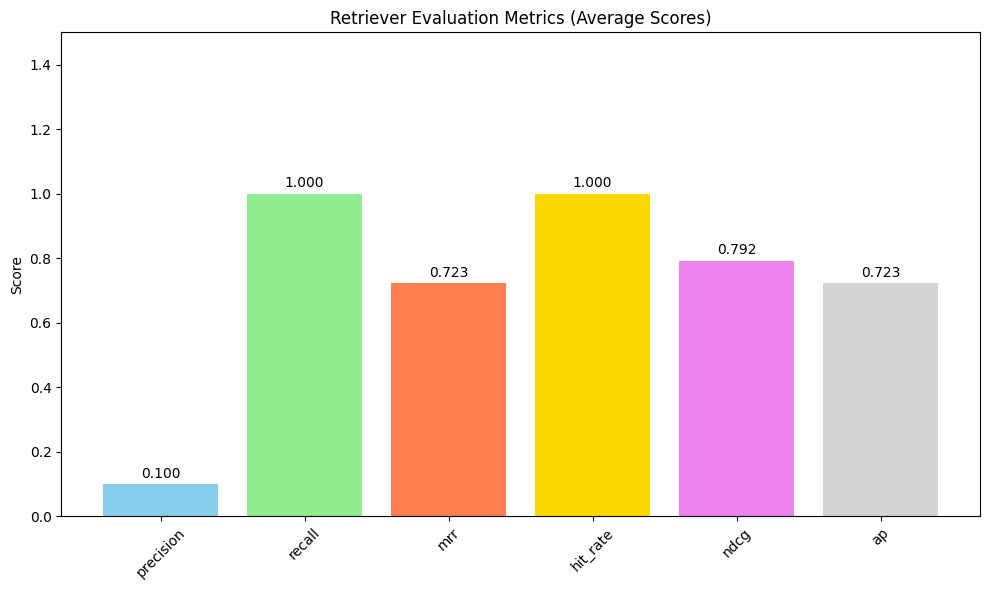

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 数据整理
results_data = []
for result in eval_results:
    row = {"query": result.query}
    for metric_name, metric_score in result.metric_dict.items():
        row[metric_name] = metric_score.score
    results_data.append(row)

# 2. 转换成DataFrame格式
df_results = pd.DataFrame(results_data)

# 3. 计算每个指标的平均值
mean_scores = df_results.mean(numeric_only=True)
print("=== 平均评估指标 ===")
print(mean_scores)

# 4. 将平均结果也加入DataFrame用于绘图
df_mean = mean_scores.reset_index()
df_mean.columns = ['Metric', 'Score']

# 5. 可视化评估结果
# 绘制平均指标条形图
plt.figure(figsize=(10, 6))
bars = plt.bar(df_mean['Metric'], df_mean['Score'], color=['skyblue', 'lightgreen', 'coral', 'gold', 'violet', 'lightgray'])
plt.title('Retriever Evaluation Metrics (Average Scores)')
plt.ylabel('Score')
plt.ylim(0, 1.5)

# 在柱子上添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# 打印详细的评估结果表格
print("\n=== 详细评估结果 ===")
df_results


=== 详细评估结果 ===


,query,precision,recall,mrr,hit_rate,ndcg,ap
0,请问英伟达计划在何时推出B100和B200，并且这些产品的供货时间是什么时候？,0.1,1.0,1.00,1.0,1.000000,1.00
1,B200A 芯片的存储器规格和预计交付时间是什么？,0.1,1.0,0.50,1.0,0.630930,0.50
2,苹果公司计划在哪一年推出其桌面机器人项目，并该设备将具备哪些主要功能？,0.1,1.0,0.50,1.0,0.630930,0.50
3,请问海光信息2024年上半年的营业收入和归母净利润分别同比增长了多少百分比？,0.1,1.0,1.00,1.0,1.000000,1.00
4,2024年上半年，腾讯控股的营收和调整后净利润分别同比增长了多少？,0.1,1.0,0.50,1.0,0.630930,0.50
5,请问本报告中提到的四家公司有哪些潜在风险？,0.1,1.0,0.20,1.0,0.386853,0.20
6,根据文本内容，股票投资评级中的“买入”、“增持”、“中性”和“减持”是如何根据股价相对于基准...,0.1,1.0,1.00,1.0,1.000000,1.00
7,根据文本内容，甬兴证券有限公司在提供投资评级时，投资者应如何对待这些评级以及报告中的信息？,0.1,1.0,1.00,1.0,1.000000,1.00
8,本报告的使用和分享有哪些限制和要求？,0.1,1.0,1.00,1.0,1.000000,1.00
9,本报告中的信息和意见是否考虑了获取报告人员的具体投资目的和财务状况？,0.1,1.0,0.25,1.0,0.430677,0.25


### 3.2.2 生成质量（Generation Quality）：

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251112143714321.png" width="800">
</div>

#### 1.忠实度


- **忠实度（Faithfulness）**：答案里的每一句话都能从上下文中找到依据吗？这是衡量RAG系统是否产生“幻觉”的关键指标。

    - 针对数据：Answer/Response（生成的答案） 与 Context（提供的上下文） 之间的关系

    - 评估方式：逻辑主张验证（自然语言推理、主张分解）

-   **举个例子：**

    -   提供的上下文：“某公司2023年总营收为100亿元，同比增长20%。”

    -   高忠实度的回答：“根据资料，该公司2023年总营收达到100亿元，增速为20%。” （答案完全基于上下文）

    -   低忠实度的回答：“该公司2023年总营收达到100亿元，增速为20%。这一增长主要得益于其海外市场的强劲表现和新产品的成功发布。” （后半句是模型基于常识或训练数据进行的“幻觉”，无法从上下文中验证）

- **计算过程**
    - 步骤1：从答案中提取主张

        - XX公司2023年营收为100亿元。

        - 营收增长率为20%。

        - 其业务主要聚焦于国内市场。

    - 步骤2：验证每个主张是否能从上下文中推断

        - 主张1：能与上下文“总营收为100亿元”对应 → 可验证

        - 主张2：能与上下文“同比增长20%”对应 → 可验证

        - 主张3：能与上下文“主要市场在中国”对应（“国内”是“中国”的同义转述）→ 可验证

    - 步骤3：计算忠实度

        - 可验证的主张数：3

        - 总主张数：3

        - 忠实度 = 3 / 3 = 100%

#### 2.答案相关性

- **答案相关性（Answer Relevancy）**：系统生成的最终答案是否直接、完整、且无冗余地回答了用户的原始问题。 它关注的是答案与问题之间的匹配质量，而不涉及答案的正确性

    - 针对数据：Answer/Response（生成的答案） 与 Question（用户问题） 之间的关系

- **举个例子：**

    - 用户问题：“请总结一下苹果公司2023年第三季度的营收情况。”

    - 高相关性的回答：“根据财报，苹果公司2023年Q3总营收为818亿美元，其中iPhone营收396亿美元，服务营收212亿美元。”（直接、聚焦、完整）

    - 低相关性的回答：“苹果公司是一家伟大的科技公司，由史蒂夫·乔布斯创立。它生产iPhone、iPad等产品，在全球都很受欢迎。公司的营收情况一直不错。”（答非所问、泛泛而谈、未解决具体问题）

- **评估通常通过以下方式：**

    - 完整性检查：答案是否涵盖了问题的所有关键方面？

    - 聚焦度分析：答案中是否包含与问题无关的内容？

    - 直接性判断：答案是否开门见山地回答问题，而不是包含大量铺垫？

- **计算逻辑** = 语义相关度 - 冗余度惩罚

#### 3.事实依据性



- **事实依据性（Groundedness）** 衡量的是：大模型生成的最终答案，在事实层面上是否能够被所提供的上下文信息完全支持和验证。 它是评估RAG系统是否产生"幻觉"或"虚构信息"的核心指标。

  -  **通俗理解**（写论文/报告版）：想象一下，你让一位助手帮你写一份报告，并给了他10份参考资料。他写的每一句话、每一个关键数据，是否都能在你给他的那10份资料里找到明确的出处或依据

  - **举个例子：**

    - 提供的上下文："某科技公司2023年研发投入为50亿元，占营收的15%。"

    - 高事实依据性的回答："根据资料，该公司2023年研发投入达50亿元，占营收比例的15%。"（答案中的每个事实都能在上下文中找到）

    - 低事实依据性的回答："该公司2023年研发投入达50亿元，占营收比例的15%。这一投入主要集中在人工智能和量子计算领域。"（后半句无法从上下文中验证，属于模型"幻觉"）

  - 计算逻辑 = 被验证为真实的主张数量 / 总主张数量


#### 4.忠实度与事实依据性对比

* 假设在一次开卷考试中：

    - 问题：法国首都是哪座城市？

        - 你手边的唯一参考资料（上下文） 上写着：“法国的首都是米兰。”

    - 场景1：你完全照抄资料
        - 你的答案：“法国的首都是米兰。”

        - 忠实度分析：✅ 高。你的答案100%源自你手边的资料，没有自己编造。

        - 事实依据性分析：❌ 低。虽然你忠实于资料，但答案本身是错的（巴黎才是正确答案）。

    - 场景2：你用自己的知识答题
        - 你的答案：“法国的首都是巴黎。”

        - 忠实度分析：❌ 低。你无视了给定的资料，答案不是从资料中来的。

        - 事实依据性分析：✅ 高。答案本身在事实层面是正确的。

    - 场景3：你结合资料和自己的猜测
        - 你的答案：“法国的首都是米兰，这座城市以时尚产业闻名。”

        - 忠实度分析：❌ 低。后半句“以时尚产业闻名”在资料中找不到，是你添加的。

        - 事实依据性分析：❌ 低。主答案“米兰”是错的，添加的内容可能正确但与核心事实错误相比已不重要。

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| 维度 | **忠实度** | **事实依据性** |
| :---: | :---: | :---: |
| **核心问题** | 你**抄**了吗？ | 你抄**对**了吗？ |
| **评估参照物** | **你手边的参考资料**（上下文） | **外部事实/标准答案**（真实世界） |
| **检查的关系** | 答案 **vs** 上下文 | 答案 **vs** 客观事实 |
| **评估焦点** | **来源的纯粹性**（是否无中生有） | **内容的正确性**（是否事实错误） |

#### 5.指标家族与适用维度映射矩阵

&emsp;&emsp;(集合级 vs 排名质量 vs 生成质量)

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| **指标家族** | **代表指标** | **是否考虑排序** | **主要适用阶段** | **典型用途** |
| :---: | :---: | :---: | :---: | :---: |
| 集合级(无序) | Precision、Recall、F1、Hit Rate、Context Relevancy | 否 | 检索/生成(粗评) | 快速比较,不区分顺序 |
| 排名质量 | MRR、MAP、nDCG、Hit@k | 是 | 检索/重排 | 精排优化、前K结果质量 |
| 生成质量 | Faithfulness、Groundedness、Answer Relevance | 否(侧重语义判定) | 生成 | 事实一致性、证据追溯 |

## 3.3 LlamaIndex评估器（Evaluators）详解

&emsp;&emsp;LlamaIndex提供了一系列预置的评估器，它们大多借助LLM的强大理解能力来对检索和生成结果进行打分。

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| **评估器** | **评估维度** | **工作原理** | **输出** | **何时使用** |
| :---: | :---: | :---: | :---: | :---: |
| `RelevancyEvaluator` | 上下文相关性、答案相关性 | LLM判断检索到的每个Node或最终答案与查询的匹配程度。 | 1-5分，并附带推理过程。 | 评估检索器或端到端QueryEngine的“相关性”。 |
| `FaithfulnessEvaluator` | 忠实度（无幻觉） | LLM逐句检查生成的答案，判断每一句话是否都能在提供的上下文中找到依据。 | “YES”或“NO”，并指出是哪句话无法被支撑。 | 评估生成环节是否出现“幻觉”。 |
| `CorrectnessEvaluator` | 正确性 | LLM比较生成的答案和标准的参考答案（Ground Truth），判断语义是否一致。 | 1-5分，并附带推理过程。 | 当你有高质量的“问题-标准答案”对时，用于评估端到端正确性。 |

### 3.3.1 代码实现：运行评估流程

&emsp;&emsp;评估流程通常包含以下步骤：

* 1.**准备评估数据集**：创建一组有代表性的“查询-标准答案”对。如果没有标准答案，至少需要一个高质量的查询列表。

* 2.**运行查询引擎**：对数据集中的每个查询，执行你的`QueryEngine`并记录结果（包括答案和`source_nodes`）。

* 3.**运行评估器**：初始化评估器，并对每个查询的结果进行评估。

* 4.**分析结果**：汇总评估分数，进行分析。

In [8]:
from llama_index.core.evaluation import (
    SemanticSimilarityEvaluator,
    FaithfulnessEvaluator,
    RelevancyEvaluator
)
from llama_index.core.node_parser import SentenceSplitter


def quick_evaluation_demo():
    """快速评估演示"""

    print("=== LlamaIndex文档切片质量评估器演示 ===\n")

    # 1. 配置API密钥（请替换为您的实际密钥）
    print("1. 配置API密钥...")
    if not os.getenv("OPENAI_API_KEY"):
        print("请设置环境变量 OPENAI_API_KEY")
        print("例如: export OPENAI_API_KEY='your-api-key-here'")
        return

    # 2. 初始化模型和评估器
    print("2. 初始化模型和评估器...")
    # embed_model = OpenAIEmbedding(model="text-embedding-3-large")
    # llm = OpenAI(model="gpt-4")

    # 创建语义相似度评估器，通过比较生成的答案与参考答案，两者在语义上的接近程度。（答案 vs 参考答案）
    semantic_evaluator = SemanticSimilarityEvaluator(
        embed_model=Settings.embed_model,
        similarity_threshold=0.8
    )
    # 创建忠实度评估器，检测幻觉，确保答案源于给定上下文（答案 vs 上下文）
    faithfulness_evaluator = FaithfulnessEvaluator(llm=Settings.llm)

    # 创建相关性评估器，评估答案与问题的匹配度及上下文的辅助作用（问题 vs 答案 vs 上下文）
    relevancy_evaluator = RelevancyEvaluator(llm=Settings.llm)

    # 3. 准备测试数据
    print("3. 准备测试数据...")
    sample_document = """
    人工智能（Artificial Intelligence，AI）是计算机科学的一个分支，
    它企图了解智能的实质，并生产出一种新的能以人类智能相似的方式做出反应的智能机器。

    机器学习是人工智能的一个核心研究领域，它使计算机有能力在不被明确编程的情况下进行学习。
    机器学习专注于计算机程序的开发，这些程序可以访问数据并使用它学习为自己。

    深度学习是机器学习的子集，它基于人工神经网络的表征学习方法。
    深度学习在图像、语音、文本等感知任务上取得了突破性进展。
    """

    # 切分文档
    splitter = SentenceSplitter(chunk_size=200, chunk_overlap=30)
    chunks = splitter.split_text(sample_document)

    print(f"文档已切分为 {len(chunks)} 个片段:")
    for i, chunk in enumerate(chunks):
        print(f"  片段 {i+1}: {chunk[:50]}...")

    # 4. 执行各项评估
    print("\n4. 执行质量评估...")

    # 测试查询和响应
    test_query = "什么是人工智能？"
    test_response = "人工智能是计算机科学的一个分支，研究如何让机器表现出智能行为。"
    test_reference = "人工智能是计算机科学的一个分支，企图了解智能的实质"

    # 语义相似度评估
    print("\n--- 语义相似度评估 ---")
    semantic_result = semantic_evaluator.evaluate(
        query=test_query,
        response=test_response,
        reference=test_reference,
        contexts=[chunks[0]]
    )
    print(f"相似度分数: {semantic_result.score:.3f}")
    print(f"是否通过: {semantic_result.passing}")
    print(f"反馈: {semantic_result.feedback}")

    # 忠实度评估
    print("\n--- 忠实度评估 ---")
    faithfulness_result = faithfulness_evaluator.evaluate(
        query=test_query,
        response=test_response,
        contexts=[chunks[0]]
    )
    print(f"忠实度分数: {faithfulness_result.score:.3f}")
    print(f"是否通过: {faithfulness_result.passing}")
    print(f"反馈: {faithfulness_result.feedback}")

    # 相关性评估
    print("\n--- 相关性评估 ---")
    relevancy_result = relevancy_evaluator.evaluate(
        query=test_query,
        response=test_response,
        contexts=[chunks[0]]
    )
    print(f"相关性分数: {relevancy_result.score:.3f}")
    print(f"是否通过: {relevancy_result.passing}")
    print(f"反馈: {relevancy_result.feedback}")

    # 5. 综合评估结果
    print("\n=== 评估总结 ===")
    metrics = {
        '语义相似度': semantic_result.score,
        '忠实度': faithfulness_result.score,
        '相关性': relevancy_result.score
    }

    for metric, score in metrics.items():
        status = "✓ 通过" if score >= 0.7 else "✗ 未通过"
        print(f"{metric}: {score:.3f} {status}")

    avg_score = sum(metrics.values()) / len(metrics)
    print(f"\n平均分数: {avg_score:.3f}")
    overall_status = "✓ 整体通过" if avg_score >= 0.7 else "✗ 整体未通过"
    print(f"整体评估: {overall_status}")

    return "评估完成！"

quick_evaluation_demo()


=== LlamaIndex文档切片质量评估器演示 ===

1. 配置API密钥...
2. 初始化模型和评估器...
3. 准备测试数据...
文档已切分为 2 个片段:
  片段 1: 人工智能（Artificial Intelligence，AI）是计算机科学的一个分支，
    它...
  片段 2: 深度学习是机器学习的子集，它基于人工神经网络的表征学习方法。
    深度学习在图像、语音、文本等感...

4. 执行质量评估...

--- 语义相似度评估 ---
相似度分数: 0.863
是否通过: True
反馈: Similarity score: 0.8628706882794472

--- 忠实度评估 ---
忠实度分数: 1.000
是否通过: True
反馈: YES

--- 相关性评估 ---
相关性分数: 1.000
是否通过: True
反馈: YES

=== 评估总结 ===
语义相似度: 0.863 ✓ 通过
忠实度: 1.000 ✓ 通过
相关性: 1.000 ✓ 通过

平均分数: 0.954
整体评估: ✓ 整体通过


'评估完成！'

## 3.4 指标在RAG不同阶段的应用与意义

&emsp;&emsp;将指标与阶段对齐是评估有效性的前提。

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- 索引阶段:评估分块(chunking)质量、嵌入(embedding)准确性与索引完整性(去重、覆盖)。目标是保留语义与概念关系,减少碎片化或冗余,确保检索“有的放矢”。可采用集合级与排名质量指标进行离线评估,例如检查嵌入空间聚类结构与近邻召回情况

- 检索阶段:以Precision@k、Recall@k、MRR、MAP、nDCG为主体,辅以Hit@k进行快速判断。重点是确保Top-K上下文既相关又全面,并且排好序,以便生成阶段有充分的证据支持

- 生成阶段:以Faithfulness、Groundedness、Answer Relevance与幻觉检测为核心,辅以集合级指标或语义相似度指标(如ROUGE/BLEU在限定场景下的参考)评估整体质量

</div>

&emsp;&emsp;RAG阶段-核心指标映射表(目标、代表性指标、代表性场景)

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| **阶段** | **核心目标** | **代表性指标** | **代表性场景** |
| :---: | :---: | :---: | :---: |
| 索引 | 分块与嵌入质量、索引完整性 | 嵌入一致性、召回抽查 | 长文档切分、知识库构建 |
| 检索 | Top-K相关性与排序质量 | P@k、R@k、MRR、MAP、nDCG、Hit@k | FAQ检索、证据选取 |
| 生成 | 事实一致与相关性 | Faithfulness、Groundedness、Relevance、幻觉检测 | 问答回答、摘要增强 |

# <center>第四阶段：使用开源框架进行评估测试</center>

## 4.1 使用Deepeval来进行评估

In [61]:
#!pip install deepeval

In [25]:
#构建黄金数据集格式
qa_res_dict = dict()

for i in range(0,len(qa_dataset.corpus.keys())):
    qa_res_dict[list(qa_dataset.queries.values())[i]] = list(qa_dataset.corpus.values())[i]

# 展示数据集
qa_res_dict

{'请问英伟达计划在何时推出B100和B200，并且这些产品的供货时间是什么时候？': '证 券 研 究 报 告 行 业 研 究\n\n中小市值\n\n行业研究/行业点评\n\n海外科技巨头持续发力 AI，龙头公司中报业绩亮眼\n\n——AI 行业点评报告\n\n行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 \n分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 \nE-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002\n\n◼ 核心观点\n\n4k: Ps AB\n海外 AI 视角：\n（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，\n英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户，并规划于 2024 年第三季后陆续供货。\n在 CoWoS-L 良率和量产 尚待整备的情况下，英伟达同步规划降规版 B200A 给其他企业客户， 并转为采用 CoWoS-S 封装技术。\nB200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。',
 'B200A 芯片的存储器规格和预计交付时间是什么？': 'B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 \n预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。\n到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。\n（2）马斯克旗下 xAI 公司发布 Grok-2 测试版。《科创板日报》8 月 14 日讯，马斯克旗 下 xAI 正式发布语言模型 Grok 2 早期预览版。\n据介绍，该系列模型具 有聊天、编码和推理等功能，包括 Grok 2 和 Grok 2 mini 两个版本， 目前正在 X 平台上进行测试，并将于本月晚些时候通过企业 API 提供 

In [15]:
from deepeval import evaluate
from deepeval.metrics import (
    AnswerRelevancyMetric,  # 答案相关性
    FaithfulnessMetric,      # 忠诚度（防幻觉）
    ContextualPrecisionMetric, # 上下文精确度
    ContextualRecallMetric,  # 上下文召回率
    # MultimodalAnswerRelevancyMetric # 多模态答案相关性
)
from deepeval.test_case import LLMTestCase
from deepeval.dataset import EvaluationDataset, Golden
from llama_index.core import VectorStoreIndex
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.core.retrievers import QueryFusionRetriever


# 1. 加载向量索引
index = VectorStoreIndex(nodes=nodes)

# 2. 向量检索器 (粗召回)
vector_retriever = index.as_retriever(
    similarity_top_k=6 # 扩大召回范围，为Reranker提供充足的候选
)

# 3. BM25检索器 (关键词补充)
bm25_retriever = BM25Retriever.from_defaults(
    nodes=nodes,
    similarity_top_k=6
)

# 4. 混合检索器 (融合结果)
retriever = QueryFusionRetriever(
    retrievers=[vector_retriever, bm25_retriever],
    similarity_top_k=6, # 融合后保留的候选数量
    num_queries=1, # 保持简单，不生成子查询
    mode="reciprocal_rerank",
    use_async=True # 必须开启异步
)

# 5. 定义精排序器 (Reranker)
reranker = SentenceTransformerRerank(
    model="/root/autodl-tmp/bge-reranker-base",
    top_n=3, # 精选出最相关的4个文档送给LLM,
)

# 6. 定义评估指标
metrics = [
    AnswerRelevancyMetric(threshold=0.7),  # 答案相关性阈值0.7
    FaithfulnessMetric(threshold=0.8),     # 忠诚度阈值0.8
    ContextualPrecisionMetric(threshold=0.6),  # 上下文精确度
    ContextualRecallMetric(threshold=0.7),    # 上下文召回率
]

# 7. 准备测试用例（黄金数据集）
dataset = EvaluationDataset(
    goldens=[
        Golden(
            input=list(qa_res_dict.keys())[0],
            expected_output=list(qa_res_dict.values())[0]
        ),
        Golden(
            input=list(qa_res_dict.keys())[1],
            expected_output=list(qa_res_dict.values())[1]
        )
    ]
)


In [16]:
from llama_index.core.query_engine import RetrieverQueryEngine

# 8.构建查询引擎
# query_engine = RetrieverQueryEngine(
#     retriever=retriever,
#     node_postprocessors=[reranker],
# )
query_engine = index.as_query_engine(similarity_top_k=5)

# 9. 执行端到端评估
def evaluate_rag():
    test_cases = []
    for golden in dataset.evals_iterator():
        # 运行查询
        response = query_engine.query(golden.input)

        # 提取检索上下文
        retrieval_context = [
            node.node.text for node in response.source_nodes
        ]

        # 创建测试用例
        test_case = LLMTestCase(
            input=golden.input,
            actual_output=response.response,
            expected_output=golden.expected_output,
            retrieval_context=retrieval_context
        )
        test_cases.append(test_case)

    # 一次性评估整批用例（关键：传入列表）
    run_result = evaluate(test_cases=test_cases, metrics=metrics)

    # 简要打印每个用例的得分（不同版本的 deepeval 输出结构可能稍有差异）
    try:
        for i, case_result in enumerate(run_result.results):
            print(f"Case {i+1}:")
            for m in case_result.metrics:
                print(f"- {getattr(m, 'name', 'metric')}: {getattr(m, 'score', 'N/A')}")
    except Exception:
        print(run_result)

    return run_result


# 10. 运行
evaluate_rag()

Output()

No test cases found, please try again.

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4.1, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4.1, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-4.1, strict=False, async_mode=True)...

...



Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4.1, reason: The score is 1.00 because the answer was fully relevant, directly addressing the storage specifications and OEM delivery timeline without any irrelevant information. Great job staying focused and concise!, error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.8, strict: False, evaluation model: gpt-4.1, reason: The score is 1.00 because there are no contradictions listed. Great job staying faithful to the retrieval context!, error: None)
  - ✅ Contextual Precision (score: 1.0, threshold: 0.6, strict: False, evaluation model: gpt-4.1, reason: The score is 1.00 because the first two nodes in the retrieval contexts directly answer the input question with quotes such as 'B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。' and '预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。', while all irrelevant nodes—such as the third node discussing '海光信息' and the fifth node 

⚠ WARNING: No hyperparameters logged.
» ]8;id=633930;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 17.85s | token cost: 0.074542 USD)
» Test Results (2 total tests):
   » Pass Rate: 100.0% | Passed: 2 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

test_results=[TestResult(name='test_case_1', success=True, metrics_data=[MetricData(name='Answer Relevancy', threshold=0.7, success=True, score=1.0, reason='The score is 1.00 because the answer was fully relevant, directly addressing the storage specifications and OEM delivery timeline without any irrelevant information. Great job staying focused and concise!', strict_mode=False, evaluation_model='gpt-4.1', error=None, evaluation_cost=0.004026, verbose_logs='Statements:\n[\n    "B200A 芯片将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠）。",\n    "B200A 芯片的总容量为 144GB 的存储器规格。",\n    "预计 OEMs 将于 2025 年上半年正式拿到 B200A 芯片。"\n] \n \nVerdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": null\n    },\n    {\n        "verdict": "yes",\n        "reason": null\n    },\n    {\n        "verdict": "yes",\n        "reason": null\n    }\n]'), MetricData(name='Faithfulness', threshold=0.8, success=True, score=1.0, reason='The score is 1.00 because there are no contradictions listed. Great job staying faithfu

EvaluationResult(test_results=[TestResult(name='test_case_1', success=True, metrics_data=[MetricData(name='Answer Relevancy', threshold=0.7, success=True, score=1.0, reason='The score is 1.00 because the answer was fully relevant, directly addressing the storage specifications and OEM delivery timeline without any irrelevant information. Great job staying focused and concise!', strict_mode=False, evaluation_model='gpt-4.1', error=None, evaluation_cost=0.004026, verbose_logs='Statements:\n[\n    "B200A 芯片将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠）。",\n    "B200A 芯片的总容量为 144GB 的存储器规格。",\n    "预计 OEMs 将于 2025 年上半年正式拿到 B200A 芯片。"\n] \n \nVerdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": null\n    },\n    {\n        "verdict": "yes",\n        "reason": null\n    },\n    {\n        "verdict": "yes",\n        "reason": null\n    }\n]'), MetricData(name='Faithfulness', threshold=0.8, success=True, score=1.0, reason='The score is 1.00 because there are no contradictions listed. Great jo

### 4.2 Trulens 框架评估

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251112144023269.png" width="800">
</div>

TruLens作为一个开源的LLM应用评估框架，通过精心设计的"RAG三元组"（RAG Triad）评估体系，为开发者提供了一套完整的、可扩展的评估解决方案。本文将从架构原理、评估指标、与LlamaIndex集成等多个维度，深入剖析TruLens的技术实现，为面试者和实践者提供全面的理解和应用指导。


In [17]:
#!pip install trulens trulens-apps-llamaindex trulens-providers-openai trulens-eval streamlit

In [33]:
from trulens.providers.openai import OpenAI as TruOpenAI
from trulens.core import Feedback, TruSession, Select
import numpy as np

def build_feedbacks(provider: TruOpenAI | None = None):
    """
    构建 RAG 三元组反馈函数：
    - Groundedness：答案是否基于提供的上下文，有推理链（CoT）
    - Answer Relevance：答案与用户查询的相关性
    - Context Relevance：上下文与用户查询的相关性

    使用新版 TruLens API（OTEL 模式）：
    - 使用 .on_input(), .on_output(), .on_context() 方法
    - 这些方法会自动从 span attributes 中提取数据
    """

    # 若未显式传入 Provider，则默认使用 OpenAI Provider
    oai = provider or TruOpenAI()

    # Answer Relevance：答案与查询的相关性
    # 从 RECORD_ROOT.INPUT 和 RECORD_ROOT.OUTPUT 获取数据
    f_answer_relevance = (
        Feedback(oai.relevance_with_cot_reasons, name="Answer Relevance")
        .on_input()   # 自动从 SpanAttributes.RECORD_ROOT.INPUT 获取
        .on_output()  # 自动从 SpanAttributes.RECORD_ROOT.OUTPUT 获取
    )

    # Groundedness：答案与上下文的一致性
    # 从 RETRIEVAL.RETRIEVED_CONTEXTS 和 RECORD_ROOT.OUTPUT 获取数据
    # 注意：groundedness_measure_with_cot_reasons 的参数顺序是 (source, statement)
    # source 是上下文列表，statement 是答案
    f_groundedness = (
        Feedback(oai.groundedness_measure_with_cot_reasons, name="Groundedness")
        .on_context(collect_list=True)  # source: 从 SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS 获取
        .on_output()  # statement: 从 SpanAttributes.RECORD_ROOT.OUTPUT 获取
    )

    # Context Relevance：上下文与查询的相关性
    # 从 RECORD_ROOT.INPUT 和 RETRIEVAL.RETRIEVED_CONTEXTS 获取数据
    # 注意：context_relevance_with_cot_reasons 的参数顺序是 (question, context)
    f_context_relevance = (
        Feedback(oai.context_relevance_with_cot_reasons, name="Context Relevance")
        .on_input()  # question: 从 SpanAttributes.RECORD_ROOT.INPUT 获取
        .on_context(collect_list=False)  # context: 从 SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS 获取，每个上下文片段单独评估
        .aggregate(np.mean)  # 对所有上下文片段的分数取平均
    )

    return [f_groundedness, f_answer_relevance, f_context_relevance]


f_list = build_feedbacks()

In [34]:
from llama_index.core import VectorStoreIndex

# 建立index索引
index = VectorStoreIndex(nodes=nodes)

# 创建查询引擎
query_engine = index.as_query_engine(similarity_top_k=5)

In [35]:
from trulens.core.otel.instrument import instrument
from trulens.otel.semconv.trace import SpanAttributes
from typing import List

class LlamaIndexRAG:
    """
    LlamaIndex RAG 的最小封装：包含检索和生成两个步骤
    - 使用 @instrument 为方法打点，以便 TruApp 记录调用的入参与返回值
    - 明确不依赖 TruLlama 或 LangChain 插件，减少版本兼容问题
    """

    def __init__(self, query_engine):
        # 保存由 LlamaIndex 构建的 QueryEngine（例如 index.as_query_engine(...))
        self.query_engine = query_engine

    @instrument(
        span_type=SpanAttributes.SpanType.RETRIEVAL,
        attributes={
            SpanAttributes.RETRIEVAL.QUERY_TEXT: "query",
            SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS: "return",
        }
    )
    def retrieve(self, query: str) -> List[str]:
        """检索相关上下文"""
        # 发起 LlamaIndex 查询
        resp = self.query_engine.query(query)

        # 兼容地提取上下文文本：常见在 resp.source_nodes
        contexts: List[str] = []
        source_nodes = getattr(resp, "source_nodes", [])

        # 遍历每个 SourceNode，尽可能获取原文内容
        for sn in source_nodes:
            text = None

            # 常见字段：sn.node 或 sn.source_node，内部可能有 text 或 get_content()
            node_obj = getattr(sn, "node", None) or getattr(sn, "source_node", None)
            if node_obj is not None:
                text = getattr(node_obj, "text", None)
                if text is None:
                    try:
                        text = node_obj.get_content()
                    except Exception:
                        pass

            # 进一步的回退尝试：直接取 sn.text 或调用 node.get_content()
            if text is None:
                text = getattr(sn, "text", None)
            if text is None:
                try:
                    node = getattr(sn, "node", None)
                    if node is not None and hasattr(node, "get_content"):
                        text = node.get_content()
                except Exception:
                    pass

            if text:
                contexts.append(text)

        return contexts

    @instrument(span_type=SpanAttributes.SpanType.GENERATION)
    def generate_answer(self, query: str, contexts: List[str]) -> str:
        """基于上下文生成答案"""
        # 这里我们直接使用 query_engine 的结果
        # 在实际应用中，这个方法会调用 LLM 生成答案
        resp = self.query_engine.query(query)

        # 兼容不同版本的响应对象：优先取 response，其次 message，最后转字符串
        ans = getattr(resp, "response", None)
        return ans

    # 把这个方法标记为“可观测”的应用调用
    @instrument(
        span_type=SpanAttributes.SpanType.RECORD_ROOT,
        attributes={
            SpanAttributes.RECORD_ROOT.INPUT: "query",
            SpanAttributes.RECORD_ROOT.OUTPUT: "return",
        }
    )
    def query(self, query: str) -> str:
        """执行完整的 RAG 流程：检索 + 生成"""
        contexts = self.retrieve(query)
        answer = self.generate_answer(query, contexts)
        return answer

In [46]:
from trulens.core import Feedback, TruSession
from trulens.apps.app import TruApp

def setup_rag_evaluator(index: VectorStoreIndex, top_k: int = 3):
    """
    设置 RAG 评估器（一次性初始化）：
    1) 创建 QueryEngine
    2) 构建反馈函数
    3) 封装为 TruApp（将反馈函数传入）
    4) 初始化 TruSession

    返回：
    (tru_rag, session) - 可复用的评估组件
    """
    # 从索引创建 QueryEngine，指定 top_k 控制检索的上下文条数
    qe = index.as_query_engine(similarity_top_k=top_k)

    # 封装为自定义 RAG
    rag = LlamaIndexRAG(qe)

    # 初始化会话（连接默认 sqlite 或指定数据库）
    session = TruSession()

    # 构建反馈函数
    feedbacks = build_feedbacks()

    # 创建 TruApp，将反馈函数传入（OTEL 模式下反馈函数会自动运行）
    tru_rag = TruApp(
        rag,
        app_name="LlamaIndex RAG",
        app_version="v1",
        feedbacks=feedbacks  # 在 OTEL 模式下，反馈函数在这里传入
    )

    return tru_rag, session


In [47]:
def evaluate_single_query(tru_rag, session, query: str):
    """
    评估单个查询（可多次调用）：
    1) 通过 TruApp 记录一次调用
    2) 反馈函数会自动运行（已在 TruApp 中配置）
    3) 返回结果

    参数：
    - tru_rag: TruApp 实例（由 setup_rag_evaluator 创建）
    - session: TruSession 实例
    - query: 用户查询

    返回：
    (answer, record)
    """
    # 记录一次查询调用：with 语句块结束后可通过 recording.get() 获取 Record
    # 在 OTEL 模式下，反馈函数会自动运行
    with tru_rag as recording:
        answer = tru_rag.app.query(query)

    record = recording.get()

    # 注意：在 OTEL 模式下，反馈函数已经自动运行
    # 不需要手动调用 session.run_feedback_functions()
    # 反馈结果会自动保存到数据库，可以通过 Dashboard 查看

    return answer, record

In [48]:
from trulens.dashboard import run_dashboard

def evaluate_query(
    index: VectorStoreIndex,
    query: str,
    top_k: int = 4,
    run_ui: bool = True,
):
    """
    对单个查询做端到端评估（兼容旧版 API）：
    1) 由索引构建 QueryEngine；
    2) 用 LlamaIndexRAG 封装并通过 TruApp 记录一次调用；
    3) 反馈函数自动运行（在 OTEL 模式下）；
    4) 可选启动 Dashboard 展示评估结果。

    返回：
    (record, session, answer)
    """
    tru_rag, session = setup_rag_evaluator(index, top_k)
    answer, record = evaluate_single_query(
        tru_rag, session, query
    )

    # 可选启动 Dashboard，查看记录、反馈分数与详细轨迹
    if run_ui:
        run_dashboard(session)

    return record, session, answer

In [49]:
query = "B200A 芯片的存储器规格是多少，预计何时由 OEMs 正式拿到？"
record, session, answer = evaluate_query(index, query)

Starting dashboard ...
Dashboard already running at path:   Local URL: http://localhost:40799



In [51]:
# 打印模型回复内容
record.main_output

'B200A 芯片的存储器规格为 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。预计 OEMs 将于 2025 年上半年正式拿到 B200A 芯片。'

In [55]:
# 打印单次对话的评估指标
record.retrieve_feedback_results()

,Groundedness,Answer Relevance,Context Relevance
record_id,,,
3d3ff2bd-cd98-450f-8be4-507292b1540f,1.0,1.0,0.5


In [54]:
# 打印同一个版本的评估指标
session.get_leaderboard()

,,Answer Relevance,Context Relevance,Groundedness,latency,total_cost
app_name,app_version,,,,,
LlamaIndex RAG,v1,1.0,0.5,1.0,10.444142,0.045789


### Trulens 启动日志打印

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251112143732818.png" width="800">
</div>

### Trulens启动UI页面展示

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251112144316370.png" width="800">
</div>

### Trulens检索数据查询

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251112143732822.png" width="800">
</div>

### 4.3 其他开源框架对比

<style>
/* 强制表格居中、自动换行并适应单元格宽度 */
.rendered_html table, .jp-RenderedHTMLCommon table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important; /* 允许表格根据内容收缩 */
    max-width: 100%; /* 防止表格溢出单元格 */
    table-layout: fixed; /* 固定布局算法，对长文本换行至关重要 */
}
.rendered_html th, .jp-RenderedHTMLCommon th,
.rendered_html td, .jp-RenderedHTMLCommon td {
    white-space: normal !important; /* 允许自动换行 */
    word-wrap: break-word; /* 对长单词或URL进行强制换行 */
    text-align: left; /* 默认内容左对齐 */
}
.rendered_html th, .jp-RenderedHTMLCommon th {
    text-align: center !important; /* 表头文本居中 */
}
</style>

| 工具名称 | 核心定位 | 突出特点 | 适用场景 |
| :---: | :---: | :---: | :---: |
| **RAGAS** | **专项评估框架** | 专为RAG设计，提供上下文相关性、答案忠实度等**核心指标的成熟实现**，被认为是该领域的领导者。 | 快速衡量RAG流水线整体表现，进行**快速迭代和基准测试**。 |
| **DeepEval** | **集成测试框架** | 提供超过14种评估指标，与`pytest`<br/>**无缝集成**，支持以编写单元测试的方式评估RAG系统。 | 适合**CI/CD管道**，追求评估自动化和工程化的团队。 |
| **TruLens** | **深度诊断工具** | 采用"Triad"评估模型，能**追踪完整的RAG调用链**，帮助定位性能瓶颈是在检索端还是生成端。 | 当需要**深入调试和根本原因分析**，而不仅仅是获得一个分数时。 |
| **Arize Phoenix** | **可观测性平台** | 开源的AI可观测性工具，提供评估和追踪能力，非常适合在**本地开发环境**中进行早期调试和迭代。 | **开发阶段**的模型观测、评估和问题排查。 |

### 4.4 参数调优：从评估到优化

&emsp;&emsp;评估的最终目的是指导优化。当你获得了一份评估报告后，应该如何解读并采取行动？

1.**低上下文相关性 (Low Context Relevancy)**

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **症状**：评估报告显示`RelevancyEvaluator`得分低（如低于3.5）。检查`source_nodes`发现大量无关内容。
  
  - **原因**：
    
    - Embedding模型与你的数据领域不匹配。
      
    - `similarity_top_k`设置过高，引入了噪声。
   
    - 文档切分（Chunking）不合理，导致Node语义模糊。
   
  - **调优策略**： 
    - **引入Reranker**：这是最直接有效的手段。增加一个`SentenceTransformerRerank`后处理器，在粗召回后进行精排。

    - **优化Chunking**：尝试更小的`chunk_size`，增加`chunk_overlap`，确保每个Node都是一个独立、完整的语义单元。
    - **更换Embedding模型**：尝试领域内更专业的Embedding模型，如针对代码、金融或医疗的模型。
   
    - **降低**`similarity_top_k`：如果不想引入Reranker，可以直接降低`top_k`，但这可能会牺牲召回率。

</div>

2.**低忠实度 (Low Faithfulness)**

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **症状**：`FaithfulnessEvaluator`报告大量“NO”，意味着答案包含幻觉。
  
  - **原因**：
  
    - 上下文信息不足或不准确（检索问题）。
    
    - LLM的自由发挥倾向过强。
   
    - Prompt设计不当。
   
  - **调优策略**：
 
    - **首先解决检索问题**：忠实度的根源往往是检索质量不高。请先按照上一条的建议提升上下文相关性。

    - **优化System Prompt**：在`QueryEngine`或`ChatEngine`中加入强约束的System Prompt，如：“你是一个严谨的AI助手，你的回答必须严格依据提供的上下文信息，禁止任何形式的推测或补充。如果上下文中没有相关信息，请直接回答‘根据提供的信息，无法回答该问题’。”
   
  
    - **调整LLM温度（Temperature）**：将`temperature`设置为0，降低LLM的随机性。

</div>

3.**答案相关性 (Low AnswerRelevancy)**

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **症状**：评估报告显示 AnswerRelevancyEvaluator 得分低，答案包含大量与问题无关的“背景知识”或“通用信息”。
  
  - **原因**：
  
    - 检索阶段污染：检索器返回的上下文（Context）本身相关性就不高，导致模型“无米下炊”或“被错误信息带偏”。
    
    - LLM 指令遵从性弱：模型的系统提示词（System Prompt）未能有效约束其行为，导致其倾向于根据内部知识“自由发挥”，而不是严格基于给定的上下文。
   
    - 问题表述模糊：用户的问题本身不够清晰，使得模型难以抓住重点。
   
  - **调优策略**：
 
    - **优化检索源头**：确保检索到的上下文具有高相关性。这需要通过前面提到的 优化Embedding模型、引入Reranker、调整Chunking策略 来解决。

    - **强化提示工程**：在系统提示词中明确指令：加入强有力的约束，例如：“请严格且仅根据提供的上下文信息来回答问题。如果上下文中的信息不足以回答问题，请直接说明‘根据已知信息无法回答该问题’，切勿编造或使用外部知识。”
  
    - **实施答案后处理与过滤**：在将答案返回给用户前，可以增加一个 “答案相关性验证” 步骤。使用一个轻量级的评估器（如同样基于LLM）对“问题-答案”对进行快速打分，如果分数过低，则触发重答或返回“无法回答”的提示。。

</div>


4.**事实依据性 (Low Groundedness)**

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **症状**：评估报告显示GroundednessEvaluator得分低，生成的答案中包含了无法在提供的上下文片段中找到支持的细节、数据或结论，答案听起来合理，但实则为模型的“幻觉”产物。
  
  - **原因**：
  
    - 检索器召回不足：上下文未能提供足够的信息来完整回答问题，迫使模型动用其内部参数进行“补全”。
    
    - LLM 指令遵从性弱：系统提示词未能有效命令模型“严格忠于上下文”，导致其固有的生成倾向占上风。
   
    - 缺乏显式的溯源要求：模型在生成时没有被强制要求将其输出与来源绑定，导致“信口开河”。
   
  - **调优策略**：
 
    - **优化检索源头**：引入 Reranker：这是提升Groundedness最有效的手段之一。Reranker能精准筛选出与问题最相关、信息密度最高的片段，为模型提供坚实的事实基础。

    - **优化 Chunking 策略**：确保文本块是语义完整、自包含的单元，避免因信息被割裂而迫使模型进行猜测。
  
    - **强化提示工程与生成约束**：“你的答案必须严格、一字一句地基于用户提供的上下文内容。绝对禁止使用任何外部知识或进行推断。对于每一个核心主张，思考它是否在上下文中被明确提及。”
   
    - **采用“引用”机制**：要求模型在生成答案时，必须为关键陈述标注来源。例如：【引用#1】, 【引用#2】。
   
    - **实施后处理验证**：构建一个轻量级的 “Groundedness校验器”。在答案生成后，此校验器会自动检查答案中的关键主张是否都能在上下文中找到对应，若发现大量无来源的主张，则可触发重生成或标记该答案为“低可信度”。

</div>


3.**低召回率 (Low Recall / Low Hit Rate)**

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **症状**：`Hit Rate`低，或者业务测试发现很多已知存在于文档中的问题回答不出来。

  - **原因**： 
          - 单一的检索策略无法覆盖所有查询类型（如纯向量检索无法处理关键词查询）。

          - `similarity_top_k`设置过低。

  - **调优策略**： 
    - **采用混合检索**：立即切换到`QueryFusionRetriever`，结合向量检索和BM25检索，这是提升召回率的“银弹”。
      
    - **查询重写/扩展**：使用`QueryFusionRetriever`的`num_queries > 1`功能，或手动实现查询扩展逻辑，生成多个子查询进行检索。
   
    - **增加**`similarity_top_k`：适当调高召回的候选集数量，特别是当后端接有Reranker时，可以大胆地将`top_k`设置为20甚至更高。

</div>

**4.迭代优化的循环**

&emsp;&emsp;参数调优不是一次性的过程，而是一个持续迭代的循环：

&emsp;&emsp;1.**建立基线**：使用默认参数运行一次完整的评估，记录所有指标，作为后续改进的基线。

&emsp;&emsp;2.**单变量原则**：每次只调整一个参数（如`chunk_size`、`top_k`或增加Reranker）。

&emsp;&emsp;3.**再次评估**：运行完整的评估流程，观察核心指标的变化。

&emsp;&emsp;4.**分析与决策**：如果指标有提升，保留该改动；如果没有或变差，则回退。分析变化的原因，为下一步调整提供思路。

&emsp;&emsp;5.**重复循环**：持续这个过程，直到达到满意的性能水平。

&emsp;&emsp;通过这个系统化的评估与调优框架，你可以将RAG系统的优化从“玄学”变为“科学”，有据可依地提升系统在各个维度的表现。

# <center>第五阶段：常见问题与优化建议

### Q1: Precision高但Recall低，怎么办？

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **原因**：检索过于保守，只敢取最相似的文档
- **优化**：
  - 增加`top_k`值
  - 使用Hybrid Search（混合关键词+向量）
  - 降低`similarity_threshold`

</div>

### Q2: Faithfulness低（幻觉严重），怎么办？

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **原因**：LLM过度发挥，使用了上下文外的知识
- **优化**：
  - **强制引用**：prompt要求"必须引用提供的文档"
  - **降低temperature**：设置`temperature=0.1`
  - **添加后处理**：用LLM检查答案是否忠实于上下文

</div>

### Q3: 评估成本太高，怎么办？

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **方案**：
  - **分层评估**：先用关键词匹配筛选，再用LLM评估难例
  - **采样评估**：每天随机抽取100条评估，而非全量
  - **缓存评估结果**：相同查询缓存评估分数

</div>

### Q4: 没有标准答案怎么评估？

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **方案**：
  - 使用**RAGAS的faithfulness**（无需参考答案）
  - 使用**LLM-as-Judge**：让GPT-4打分
  - **A/B测试**：线上对比不同版本的用户满意度

</div>

## <center>第六阶段：生产环境RAG评估定位

在企业级应用中，RAG（Retrieval-Augmented Generation）并不是“一次性上线”的静态系统，而是一个可监控、可迭代优化的智能系统。
评估不是“离线跑几次指标”，而是：**贯穿 RAG 全生命周期的质量闭环体系（Continuous RAG Evaluation Loop）**

在生产环境中，RAG评估应该是"全程监控+重点突破"的模式。平时通过监控体系保持系统健康，当发现具体问题时，采用"单阶段深度评估+全链路影响分析"的方法进行精准优化。

| 目标         | 推荐做法                                               |
| ------------ | ------------------------------------------------------ |
| **持续改进** | 建立自动化评估管道（Ragas/TruLens + LlamaIndex）       |
| **指标追踪** | 对 Precision、Recall、MRR、Faithfulness 等进行时序监控 |
| **版本控制** | 对每次索引、模型、prompt、retriever 参数版本化         |
| **人工复核** | 周期抽样人工检查模型输出                               |
| **异常报警** | 结合日志系统（Prometheus/Grafana）监控延迟、异常       |

* TruLens官网地址：https://www.trulens.org/

* RAGas官网地址：https://docs.ragas.io/en/latest/

* DeepEval官网地址：https://deepeval.com/

* Arize Phoenix官网地址：https://phoenix.arize.com/